## 1. Environment and reproducibility

Run the notebook in Google Colab with GPU acceleration. The fixed dataset location is `/content/gdrive/MyDrive/dataset/waterborne`, matching the supplied working code. No recursive file search or automatic split generation is performed.


In [ ]:
!pip -q install -U "timm>=1.0.15" "albumentations>=1.4.20" pycocotools seaborn scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.6 MB/s eta 0:00:00


In [ ]:
import os, json, math, random, warnings
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from pycocotools import mask as mask_utils

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, matthews_corrcoef, cohen_kappa_score,
    log_loss
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

try:
    from google.colab import drive
    if not Path("/content/gdrive/MyDrive").exists():
        drive.mount("/content/gdrive")
except Exception:
    print("Google Drive mount skipped. Confirm that /content/gdrive/MyDrive is available.")

@dataclass
class CFG:
    data_root: str = "/content/gdrive/MyDrive/dataset/waterborne"
    output_dir: str = "/content/gdrive/MyDrive/dataset/waterborne/q1_outputs"
    encoder: str = "convnextv2_tiny.fcmae_ft_in22k_in1k"
    image_size: int = 384
    batch_size: int = 8
    epochs: int = 60
    patience: int = 12
    lr: float = 2e-4
    weight_decay: float = 1e-4
    num_workers: int = 2
    seed: int = 42
    label_smoothing: float = 0.05
    seg_weight: float = 1.0
    cls_weight: float = 0.7
    boundary_weight: float = 0.15
    grad_clip: float = 1.0
    use_weighted_sampler: bool = True
    resume_training: bool = True
    save_every_epoch: bool = True

cfg = CFG()
DATA_ROOT = Path(cfg.data_root)
OUT = Path(cfg.output_dir)
FIG_DIR, TABLE_DIR, CKPT_DIR = OUT / "figures", OUT / "tables", OUT / "checkpoints"
for folder in (FIG_DIR, TABLE_DIR, CKPT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(json.dumps(asdict(cfg), indent=2))


Mounted at /content/gdrive
Device: cuda
{
  "data_root": "/content/gdrive/MyDrive/dataset/waterborne",
  "output_dir": "/content/gdrive/MyDrive/dataset/waterborne/q1_outputs",
  "encoder": "convnextv2_tiny.fcmae_ft_in22k_in1k",
  "image_size": 384,
  "batch_size": 8,
  "epochs": 60,
  "patience": 12,
  "lr": 0.0002,
  "weight_decay": 0.0001,
  "num_workers": 2,
  "seed": 42,
  "label_smoothing": 0.05,
  "seg_weight": 1.0,
  "cls_weight": 0.7,
  "boundary_weight": 0.15,
  "grad_clip": 1.0,
  "use_weighted_sampler": true,
  "resume_training": true,
  "save_every_epoch": true
}


In [ ]:
# Consistent Viridis journal palette. Saved figures are 300 DPI in PNG and PDF.
VIRIDIS = mpl.colormaps["viridis"]
PALETTE = [mpl.colors.to_hex(VIRIDIS(v)) for v in np.linspace(0.08, 0.92, 6)]
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 1.1,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})
sns.set_style("whitegrid", {"grid.linestyle": ":", "grid.alpha": 0.35})

def save_figure(fig, stem, tight=True):
    kwargs = {"dpi": 300, "bbox_inches": "tight" if tight else None, "pad_inches": 0.04}
    fig.savefig(FIG_DIR / f"{stem}.png", **kwargs)
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight" if tight else None, pad_inches=0.04)
    print(f"Saved: {FIG_DIR / (stem + '.png')}")


## 2. COCO audit and split integrity

The official `train`, `valid`, and `test` folders are used when all three annotation files are present. The audit reports class counts, images containing more than one pathogen class, missing files, duplicate filenames across splits, and the available annotation geometry.


In [ ]:
import glob
from collections import OrderedDict

base_dir = "/content/gdrive/MyDrive/dataset/waterborne"
splits = OrderedDict({
    "train": os.path.join(base_dir, "train"),
    "valid": os.path.join(base_dir, "valid"),
    "test": os.path.join(base_dir, "test"),
})
image_exts = ("*.jpg", "*.jpeg", "*.png")

def list_class_folders(split_dir):
    if not os.path.isdir(split_dir):
        return []
    return sorted([
        name for name in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, name))
    ])

def count_files_in_dir(dir_path, extensions):
    return sum(len(glob.glob(os.path.join(dir_path, ext))) for ext in extensions)

def count_files_recursive(dir_path, extensions):
    return sum(len(glob.glob(os.path.join(dir_path, "**", ext), recursive=True)) for ext in extensions)

summary = {}
for split, split_dir in splits.items():
    if not os.path.isdir(split_dir):
        summary[split] = {"total": 0, "per_class": {}}
        continue
    class_folders = list_class_folders(split_dir)
    if class_folders:
        per_class = {
            class_name: count_files_in_dir(os.path.join(split_dir, class_name), image_exts)
            for class_name in class_folders
        }
        total = sum(per_class.values())
    else:
        per_class = {}
        total = count_files_recursive(split_dir, image_exts)
    summary[split] = {"total": total, "per_class": per_class}

print("=== Split totals ===")
for split in summary:
    print(f"{split:>5}: {summary[split]['total']} images")

print("\n=== Per-class (only if class folders exist) ===")
for split in summary:
    if summary[split]["per_class"]:
        print(f"\n[{split}]")
        for class_name, count in summary[split]["per_class"].items():
            print(f"  {class_name}: {count}")

def load_coco_split(split):
    image_dir = Path(splits[split])
    ann_path = image_dir / "_annotations.coco.json"
    if not image_dir.is_dir():
        raise FileNotFoundError(f"Missing split directory: {image_dir}")
    if not ann_path.is_file():
        raise FileNotFoundError(f"Missing annotation file: {ann_path}")
    with open(ann_path, "r", encoding="utf-8") as file:
        coco = json.load(file)
    return coco, image_dir, ann_path

split_data = {split: load_coco_split(split) for split in ("train", "valid", "test")}

# Build a single class order from the training annotation categories.
train_coco = split_data["train"][0]
train_ann_counts = Counter(a["category_id"] for a in train_coco["annotations"])
valid_category_ids = [
    c["id"] for c in sorted(train_coco["categories"], key=lambda z: z["id"])
    if train_ann_counts.get(c["id"], 0) > 0 and c["name"].strip().lower() != "pathogens"
]
category_id_to_name = {c["id"]: c["name"] for c in train_coco["categories"]}
category_id_to_mask = {cid: i + 1 for i, cid in enumerate(valid_category_ids)}
category_id_to_label = {cid: i for i, cid in enumerate(valid_category_ids)}
class_names = [category_id_to_name[cid] for cid in valid_category_ids]
mask_names = ["Background"] + class_names
NUM_CLASSES = len(class_names)
NUM_MASK_CLASSES = NUM_CLASSES + 1

print("Image classes:", class_names)
print("Mask classes:", mask_names)
print("Outputs:", OUT)


=== Split totals ===
train: 1055 images
valid: 301 images
 test: 151 images

=== Per-class (only if class folders exist) ===
Image classes: ['Astrovirus', 'Cryptosporidium', 'Giardia', 'Norovirus', 'Rotavirus']
Mask classes: ['Background', 'Astrovirus', 'Cryptosporidium', 'Giardia', 'Norovirus', 'Rotavirus']
Outputs: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs


In [ ]:
def annotation_geometry(ann):
    seg = ann.get("segmentation")
    if isinstance(seg, list) and len(seg) > 0:
        return "polygon"
    if isinstance(seg, dict) and "counts" in seg:
        return "rle"
    return "bbox"

def audit_split(split, coco, image_dir):
    image_info = {im["id"]: im for im in coco["images"]}
    anns_by_image = defaultdict(list)
    for ann in coco["annotations"]:
        if ann["category_id"] in valid_category_ids:
            anns_by_image[ann["image_id"]].append(ann)

    rows, missing, multi_class = [], [], 0
    geometry = Counter()
    for image_id, im in image_info.items():
        path = image_dir / im["file_name"]
        if not path.exists():
            missing.append(im["file_name"])
        anns = anns_by_image.get(image_id, [])
        present = sorted({a["category_id"] for a in anns})
        multi_class += int(len(present) > 1)
        for a in anns:
            geometry[annotation_geometry(a)] += 1
        rows.append({
            "split": split,
            "image_id": image_id,
            "file_name": im["file_name"],
            "width": im["width"],
            "height": im["height"],
            "annotations": len(anns),
            "classes_in_image": len(present),
        })
    return pd.DataFrame(rows), missing, multi_class, geometry

audit_frames, audit_summary = [], []
split_filenames = {}
for split, (coco, image_dir, _) in split_data.items():
    frame, missing, multi, geometry = audit_split(split, coco, image_dir)
    audit_frames.append(frame)
    split_filenames[split] = set(frame["file_name"])
    audit_summary.append({
        "Split": split.title(), "Images": len(frame),
        "Annotations": int(frame["annotations"].sum()),
        "Multi-class images": multi, "Missing files": len(missing),
        "Polygon/RLE annotations": geometry["polygon"] + geometry["rle"],
        "Box-only annotations": geometry["bbox"],
    })

audit_df = pd.concat(audit_frames, ignore_index=True)
audit_table = pd.DataFrame(audit_summary)
display(audit_table)
audit_table.to_csv(TABLE_DIR / "dataset_split_audit.csv", index=False)

overlaps = {
    "train-valid": len(split_filenames["train"] & split_filenames["valid"]),
    "train-test": len(split_filenames["train"] & split_filenames["test"]),
    "valid-test": len(split_filenames["valid"] & split_filenames["test"]),
}
print("Duplicate filenames across splits:", overlaps)
if any(overlaps.values()):
    raise ValueError("Potential split leakage: duplicate filenames occur across official splits.")

has_dense_masks = audit_table["Polygon/RLE annotations"].sum() > 0
TASK_NAME = "segmentation" if has_dense_masks else "box-supervised localization"
print("Pixel-level task interpretation:", TASK_NAME)


,Split,Images,Annotations,Multi-class images,Missing files,Polygon/RLE annotations,Box-only annotations
0,Train,1055,6430,0,0,6425,5
1,Valid,301,1668,0,0,1668,0
2,Test,151,924,0,0,924,0


Duplicate filenames across splits: {'train-valid': 0, 'train-test': 0, 'valid-test': 0}
Pixel-level task interpretation: segmentation


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig01_class_distribution.png


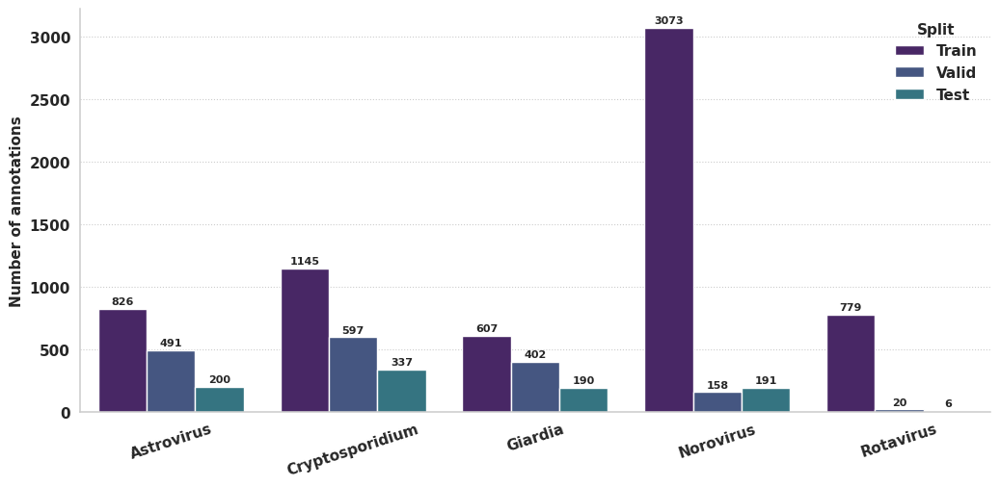

In [ ]:
def class_distribution(coco, split):
    counts = Counter(a["category_id"] for a in coco["annotations"] if a["category_id"] in valid_category_ids)
    return pd.DataFrame({
        "Split": split.title(),
        "Class": class_names,
        "Annotations": [counts[cid] for cid in valid_category_ids]
    })

dist_df = pd.concat([
    class_distribution(split_data[s][0], s) for s in ("train", "valid", "test")
], ignore_index=True)
dist_df.to_csv(TABLE_DIR / "class_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(10.5, 5.2))
sns.barplot(data=dist_df, x="Class", y="Annotations", hue="Split", palette=PALETTE[:3], ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Number of annotations")
ax.tick_params(axis="x", rotation=18)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=8, fontweight="bold")
sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig01_class_distribution")
plt.show()


## 3. Dataset and mask construction

Polygon and RLE annotations are rasterized when available. A rectangle is used only for annotations that lack mask geometry. Images containing more than one pathogen class are excluded from the single-label classification branch and retained for localization. Their count is written to the split manifest.


In [ ]:
def decode_annotation_mask(ann, height, width):
    seg = ann.get("segmentation")
    if isinstance(seg, list) and len(seg) > 0:
        rles = mask_utils.frPyObjects(seg, height, width)
        decoded = mask_utils.decode(rles)
        if decoded.ndim == 3:
            decoded = decoded.max(axis=2)
        return decoded.astype(np.uint8)
    if isinstance(seg, dict) and "counts" in seg:
        return mask_utils.decode(seg).astype(np.uint8)

    x, y, w, h = ann["bbox"]
    x1, y1 = max(0, int(np.floor(x))), max(0, int(np.floor(y)))
    x2, y2 = min(width, int(np.ceil(x + w))), min(height, int(np.ceil(y + h)))
    out = np.zeros((height, width), dtype=np.uint8)
    out[y1:y2, x1:x2] = 1
    return out

def build_records(split, coco, image_dir):
    anns_by_image = defaultdict(list)
    for ann in coco["annotations"]:
        if ann["category_id"] in valid_category_ids:
            anns_by_image[ann["image_id"]].append(ann)

    records = []
    for im in coco["images"]:
        anns = anns_by_image.get(im["id"], [])
        present = sorted({a["category_id"] for a in anns})
        label = category_id_to_label[present[0]] if len(present) == 1 else -1
        records.append({
            "split": split,
            "image_id": im["id"],
            "file_name": im["file_name"],
            "path": str(image_dir / im["file_name"]),
            "height": im["height"], "width": im["width"],
            "annotations": anns, "label": label,
            "single_label": label >= 0,
        })
    return records

records = {
    split: build_records(split, coco, image_dir)
    for split, (coco, image_dir, _) in split_data.items()
}

manifest_rows = []
for split, split_records in records.items():
    for r in split_records:
        manifest_rows.append({
            "split": split, "image_id": r["image_id"], "file_name": r["file_name"],
            "classification_label": r["label"], "single_label": r["single_label"],
            "annotation_count": len(r["annotations"])
        })
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(TABLE_DIR / "sample_manifest.csv", index=False)
display(manifest_df.groupby("split").agg(images=("image_id", "size"), single_label_images=("single_label", "sum")))


,images,single_label_images
split,,
test,151,151
train,1055,1055
valid,301,301


In [ ]:
train_aug = A.Compose([
    A.Resize(cfg.image_size, cfg.image_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.04, scale_limit=0.10, rotate_limit=15,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.55),
    A.OneOf([
        A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.12, hue=0.04, p=1),
        A.CLAHE(clip_limit=2.0, p=1),
    ], p=0.35),
    A.GaussNoise(std_range=(0.01, 0.035), p=0.15),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

eval_aug = A.Compose([
    A.Resize(cfg.image_size, cfg.image_size),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class WaterPathDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def _mask(self, record):
        mask = np.zeros((record["height"], record["width"]), dtype=np.uint8)
        # Larger annotations are written first; smaller regions remain visible.
        anns = sorted(record["annotations"], key=lambda a: a.get("area", a["bbox"][2] * a["bbox"][3]), reverse=True)
        for ann in anns:
            binary = decode_annotation_mask(ann, record["height"], record["width"])
            mask[binary > 0] = category_id_to_mask[ann["category_id"]]
        return mask

    def __getitem__(self, index):
        record = self.records[index]
        image = cv2.imread(record["path"], cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(record["path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = self._mask(record)
        transformed = self.transform(image=image, mask=mask)
        return {
            "image": transformed["image"].float(),
            "mask": transformed["mask"].long(),
            "label": torch.tensor(record["label"], dtype=torch.long),
            "class_valid": torch.tensor(record["single_label"], dtype=torch.bool),
            "image_id": str(record["image_id"]),
            "file_name": record["file_name"],
        }

train_ds = WaterPathDataset(records["train"], train_aug)
train_eval_ds = WaterPathDataset(records["train"], eval_aug)
valid_ds = WaterPathDataset(records["valid"], eval_aug)
test_ds = WaterPathDataset(records["test"], eval_aug)

train_labels = [r["label"] for r in records["train"] if r["label"] >= 0]
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights = len(train_labels) / (NUM_CLASSES * np.maximum(class_counts, 1))
sample_weights = [class_weights[r["label"]] if r["label"] >= 0 else 1.0 for r in records["train"]]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True) if cfg.use_weighted_sampler else None

loader_kwargs = dict(batch_size=cfg.batch_size, num_workers=cfg.num_workers,
                     pin_memory=torch.cuda.is_available(), persistent_workers=cfg.num_workers > 0)
train_loader = DataLoader(train_ds, shuffle=sampler is None, sampler=sampler, **loader_kwargs)
valid_loader = DataLoader(valid_ds, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

print({"train": len(train_ds), "valid": len(valid_ds), "test": len(test_ds)})
print("Training image-class counts:", dict(zip(class_names, class_counts.tolist())))


{'train': 1055, 'valid': 301, 'test': 151}
Training image-class counts: {'Astrovirus': 164, 'Cryptosporidium': 183, 'Giardia': 140, 'Norovirus': 284, 'Rotavirus': 284}


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig02_representative_samples.png


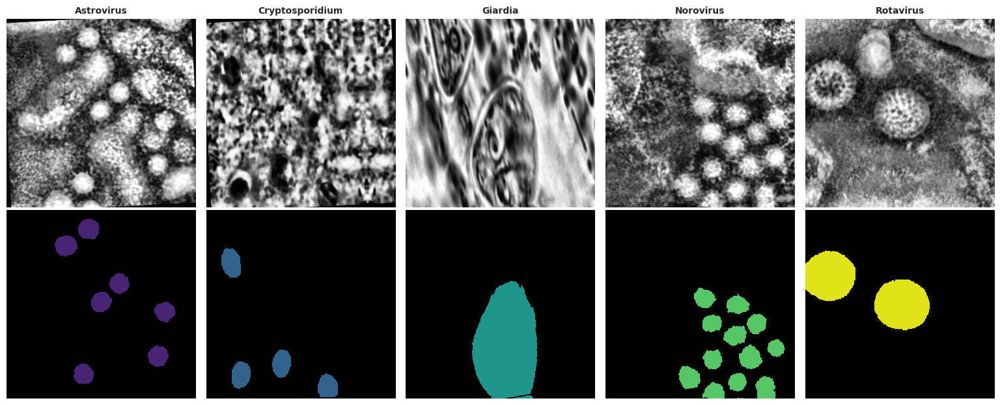

In [ ]:
# Five representative samples with annotation geometry.
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

MASK_COLORS = ["#000000"] + [mpl.colors.to_hex(VIRIDIS(v)) for v in np.linspace(0.10, 0.95, NUM_CLASSES)]
mask_cmap = mpl.colors.ListedColormap(MASK_COLORS)
mask_norm = mpl.colors.BoundaryNorm(np.arange(-0.5, NUM_MASK_CLASSES + 0.5), NUM_MASK_CLASSES)

chosen = []
for label in range(NUM_CLASSES):
    candidates = [i for i, r in enumerate(records["train"]) if r["label"] == label]
    if candidates:
        chosen.append(candidates[0])

fig, axes = plt.subplots(2, len(chosen), figsize=(3.1 * len(chosen), 6.3))
for col, idx in enumerate(chosen):
    sample = train_ds[idx]
    axes[0, col].imshow(denormalize(sample["image"]))
    axes[0, col].set_title(class_names[sample["label"].item()], fontsize=10)
    axes[1, col].imshow(sample["mask"], cmap=mask_cmap, norm=mask_norm, interpolation="nearest")
    for ax in axes[:, col]: ax.axis("off")
axes[0, 0].set_ylabel("Image", fontweight="bold")
axes[1, 0].set_ylabel("Reference region", fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig02_representative_samples")
plt.show()


### 3.1 Image dimensions, annotation density, and region scale

These panels document the input geometry before resizing. The region-area distribution is calculated from COCO bounding boxes relative to each source image and is shown on a logarithmic axis because small annotated regions can otherwise be compressed near zero.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig02a_input_geometry_and_annotation_scale.png


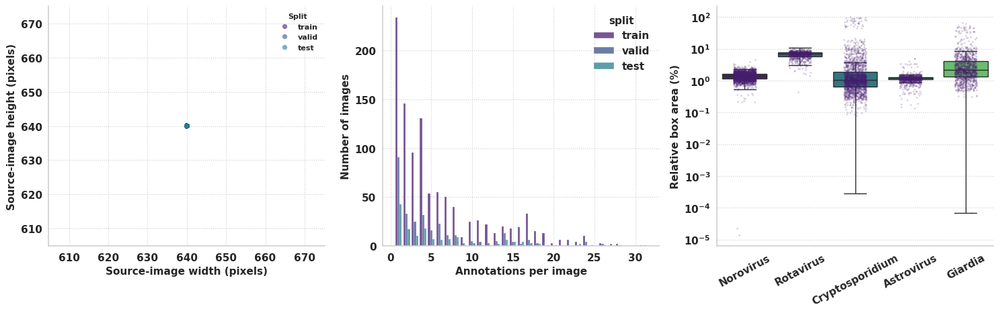

In [ ]:
bbox_rows = []
for split, split_records in records.items():
    for record in split_records:
        image_area = max(record["height"] * record["width"], 1)
        for ann in record["annotations"]:
            _, _, box_width, box_height = ann["bbox"]
            bbox_rows.append({
                "Split": split.title(),
                "Class": category_id_to_name[ann["category_id"]],
                "Relative box area (%)": 100.0 * box_width * box_height / image_area,
            })
bbox_df = pd.DataFrame(bbox_rows)
bbox_df.to_csv(TABLE_DIR / "annotation_region_geometry.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8))
sns.scatterplot(data=audit_df, x="width", y="height", hue="split", palette=PALETTE[:3],
                alpha=0.60, s=28, edgecolor="none", ax=axes[0])
axes[0].set_xlabel("Source-image width (pixels)")
axes[0].set_ylabel("Source-image height (pixels)")
axes[0].legend(title="Split", fontsize=8, title_fontsize=8)

sns.histplot(data=audit_df, x="annotations", hue="split", palette=PALETTE[:3],
             multiple="dodge", discrete=True, shrink=0.78, ax=axes[1])
axes[1].set_xlabel("Annotations per image")
axes[1].set_ylabel("Number of images")

sns.boxplot(data=bbox_df, x="Class", y="Relative box area (%)", hue="Class",
            palette=PALETTE[:NUM_CLASSES], legend=False, showfliers=False, ax=axes[2])
sns.stripplot(data=bbox_df, x="Class", y="Relative box area (%)", color=PALETTE[0],
              alpha=0.20, size=2, jitter=0.20, ax=axes[2])
axes[2].set_yscale("log")
axes[2].set_xlabel("")
axes[2].set_ylabel("Relative box area (%)")
axes[2].tick_params(axis="x", rotation=28)
for ax in axes: sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig02a_input_geometry_and_annotation_scale")
plt.show()


### 3.2 Preprocessing and augmentation stages

The preprocessing panel uses one source image to show the visual effect of resizing, geometric transformation, contrast adjustment, color perturbation, Gaussian noise, and ImageNet normalization. The normalized tensor is display-rescaled only for visualization; the model receives the standardized tensor directly.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig02b_preprocessing_stages.png


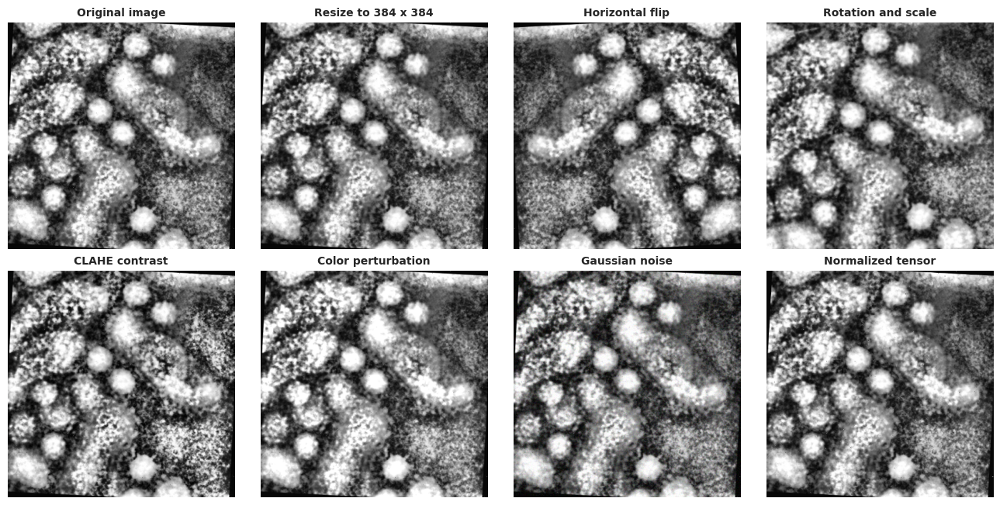

In [ ]:
preview_record = records["train"][chosen[0]]
preview_bgr = cv2.imread(preview_record["path"], cv2.IMREAD_COLOR)
preview_rgb = cv2.cvtColor(preview_bgr, cv2.COLOR_BGR2RGB)
preview_mask = train_eval_ds._mask(preview_record)
resized = cv2.resize(preview_rgb, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_AREA)

flipped = cv2.flip(resized, 1)
center = (cfg.image_size / 2, cfg.image_size / 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 12, 1.04)
rotated = cv2.warpAffine(resized, rotation_matrix, (cfg.image_size, cfg.image_size),
                         flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)
lab[:, :, 0] = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(lab[:, :, 0])
clahe_image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

hsv = cv2.cvtColor(resized, cv2.COLOR_RGB2HSV).astype(np.float32)
hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 1.14, 0, 255)
hsv[:, :, 2] = np.clip(hsv[:, :, 2] * 1.08, 0, 255)
color_adjusted = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

noise_rng = np.random.default_rng(cfg.seed)
noisy = np.clip(resized.astype(np.float32) + noise_rng.normal(0, 7.0, resized.shape), 0, 255).astype(np.uint8)

normalized_tensor = eval_aug(image=preview_rgb, mask=preview_mask)["image"].permute(1, 2, 0).numpy()
normalized_display = (normalized_tensor - normalized_tensor.min(axis=(0, 1), keepdims=True))
normalized_display /= normalized_display.max(axis=(0, 1), keepdims=True).clip(min=1e-6)

preprocessing_panels = [
    (preview_rgb, "Original image"), (resized, f"Resize to {cfg.image_size} x {cfg.image_size}"),
    (flipped, "Horizontal flip"), (rotated, "Rotation and scale"),
    (clahe_image, "CLAHE contrast"), (color_adjusted, "Color perturbation"),
    (noisy, "Gaussian noise"), (normalized_display, "Normalized tensor")
]
fig, axes = plt.subplots(2, 4, figsize=(13.2, 6.6))
for ax, (image, label) in zip(axes.flat, preprocessing_panels):
    ax.imshow(image)
    ax.set_title(label, fontsize=10)
    ax.axis("off")
fig.tight_layout()
save_figure(fig, "fig02b_preprocessing_stages")
plt.show()


### 3.3 Paired image-mask augmentation and normalized batch

Geometric operations are applied jointly to the image and reference mask. This check is important because independently transformed masks would introduce label misalignment. The second panel displays an actual training batch after normalization and class-balanced sampling.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig02c_paired_image_mask_augmentation.png


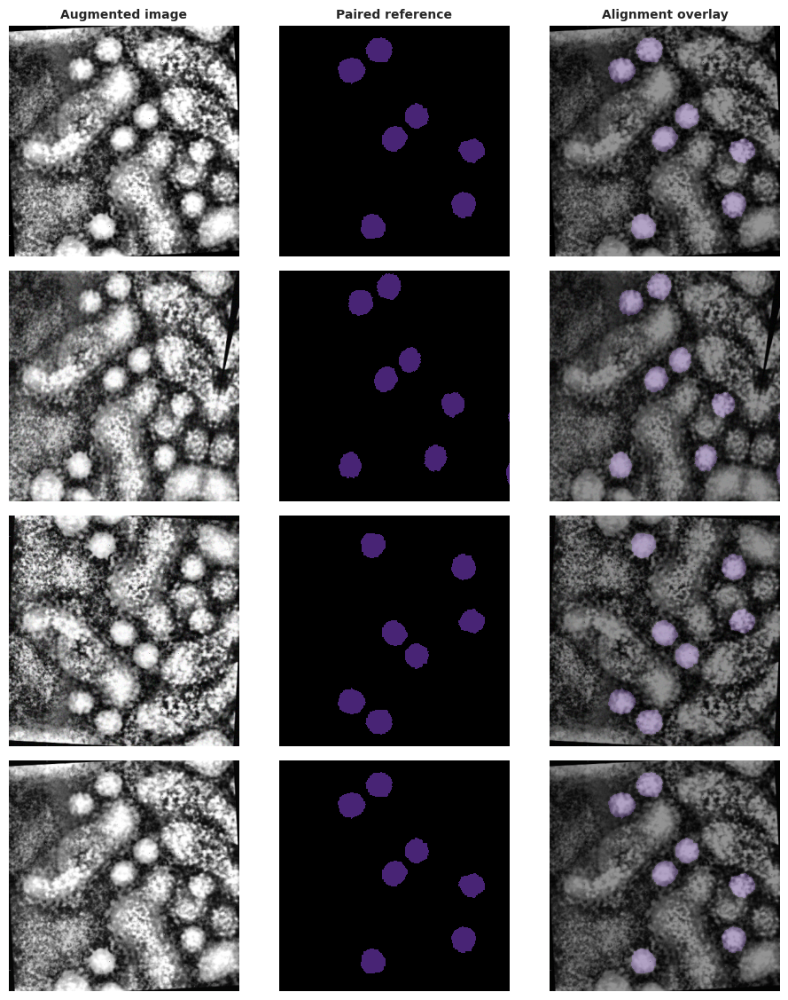

Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig02d_normalized_training_batch.png


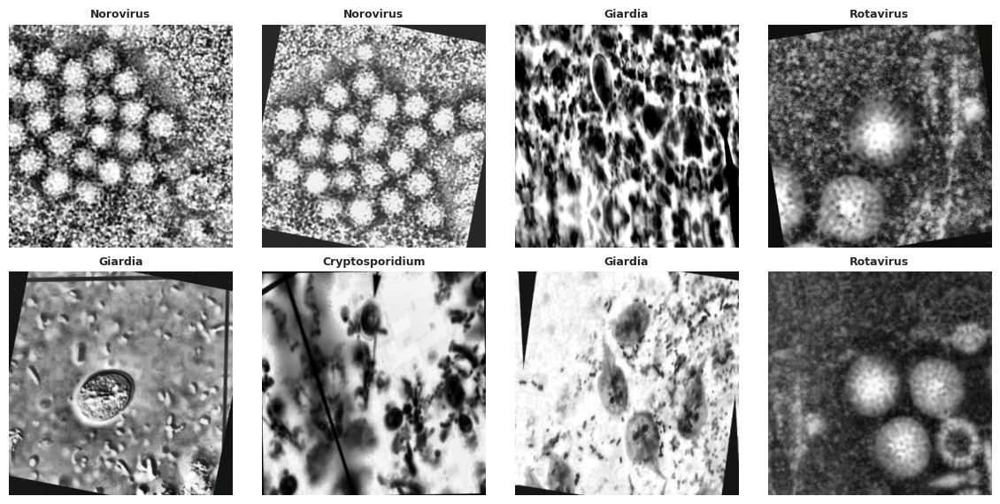

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(9.6, 11.4))
for row in range(4):
    augmented = train_aug(image=preview_rgb, mask=preview_mask)
    aug_image = denormalize(augmented["image"])
    aug_mask = augmented["mask"].numpy()
    axes[row, 0].imshow(aug_image)
    axes[row, 1].imshow(aug_mask, cmap=mask_cmap, norm=mask_norm, interpolation="nearest")
    axes[row, 2].imshow(aug_image)
    axes[row, 2].imshow(aug_mask, cmap=mask_cmap, norm=mask_norm, alpha=0.42, interpolation="nearest")
    for ax in axes[row]: ax.axis("off")
for col, label in enumerate(["Augmented image", "Paired reference", "Alignment overlay"]):
    axes[0, col].set_title(label, fontsize=10)
fig.tight_layout()
save_figure(fig, "fig02c_paired_image_mask_augmentation")
plt.show()

preview_batch = next(iter(train_loader))
n_preview = min(8, preview_batch["image"].size(0))
fig, axes = plt.subplots(2, 4, figsize=(11.6, 5.8))
for i, ax in enumerate(axes.flat):
    if i < n_preview:
        ax.imshow(denormalize(preview_batch["image"][i]))
        label_id = int(preview_batch["label"][i])
        label = class_names[label_id] if label_id >= 0 else "Multi-class"
        ax.set_title(label, fontsize=9)
    ax.axis("off")
fig.tight_layout()
save_figure(fig, "fig02d_normalized_training_batch")
plt.show()


## 4. Advanced shared-encoder multi-task model

The network uses a pretrained ConvNeXt V2 encoder. A feature pyramid combines four resolution levels for localization. The classification branch fuses global context with a foreground-weighted regional descriptor derived from the localization probabilities. The two tasks are optimized jointly, while images that contain several pathogen categories contribute only to localization loss.


In [ ]:
class ConvBNAct(nn.Sequential):
    def __init__(self, in_ch, out_ch, kernel=3):
        super().__init__(
            nn.Conv2d(in_ch, out_ch, kernel, padding=kernel // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

class FPNDecoder(nn.Module):
    def __init__(self, channels, width=192):
        super().__init__()
        self.lateral = nn.ModuleList([nn.Conv2d(c, width, 1) for c in channels])
        self.smooth = nn.ModuleList([ConvBNAct(width, width) for _ in channels])
        self.fuse = nn.Sequential(
            ConvBNAct(width * len(channels), width),
            nn.Dropout2d(0.10),
            ConvBNAct(width, width),
        )

    def forward(self, features):
        target_size = features[0].shape[-2:]
        pyramid = []
        top = None
        for i in reversed(range(len(features))):
            lateral = self.lateral[i](features[i])
            top = lateral if top is None else lateral + F.interpolate(top, size=lateral.shape[-2:], mode="bilinear", align_corners=False)
            pyramid.append(F.interpolate(self.smooth[i](top), size=target_size, mode="bilinear", align_corners=False))
        return self.fuse(torch.cat(pyramid[::-1], dim=1))

class ROIGatedClassifier(nn.Module):
    def __init__(self, in_ch, num_classes, hidden=512):
        super().__init__()
        self.global_proj = nn.Linear(in_ch, hidden)
        self.roi_proj = nn.Linear(in_ch, hidden)
        self.gate = nn.Sequential(nn.Linear(hidden * 2, hidden), nn.Sigmoid())
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Dropout(0.25), nn.Linear(hidden, num_classes))

    def forward(self, deepest, foreground_probability):
        global_vec = F.adaptive_avg_pool2d(deepest, 1).flatten(1)
        roi = F.interpolate(foreground_probability, size=deepest.shape[-2:], mode="bilinear", align_corners=False)
        roi = roi / roi.sum(dim=(2, 3), keepdim=True).clamp_min(1e-6)
        roi_vec = (deepest * roi).sum(dim=(2, 3))
        g, r = self.global_proj(global_vec), self.roi_proj(roi_vec)
        alpha = self.gate(torch.cat([g, r], dim=1))
        return self.head(alpha * r + (1.0 - alpha) * g)

class WaterPathMTLNet(nn.Module):
    def __init__(self, encoder_name, num_mask_classes, num_image_classes, pretrained=True):
        super().__init__()
        self.encoder = timm.create_model(
            encoder_name, pretrained=pretrained, features_only=True, out_indices=(0, 1, 2, 3)
        )
        channels = self.encoder.feature_info.channels()
        self.decoder = FPNDecoder(channels, width=192)
        self.segmentation_head = nn.Conv2d(192, num_mask_classes, 1)
        self.classifier = ROIGatedClassifier(channels[-1], num_image_classes)

    def forward(self, x):
        output_size = x.shape[-2:]
        features = self.encoder(x)
        decoded = self.decoder(features)
        seg_logits = self.segmentation_head(decoded)
        seg_logits = F.interpolate(seg_logits, size=output_size, mode="bilinear", align_corners=False)
        foreground = 1.0 - torch.softmax(seg_logits, dim=1)[:, :1]
        cls_logits = self.classifier(features[-1], foreground)
        return {"seg_logits": seg_logits, "cls_logits": cls_logits, "foreground": foreground}

model = WaterPathMTLNet(cfg.encoder, NUM_MASK_CLASSES, NUM_CLASSES).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable / 1e6:.2f} M")


model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

Trainable parameters: 32.45 M


## 5. Losses, optimization, and model selection

Localization combines class-weighted cross-entropy, foreground Dice loss, and a boundary-consistency term. Image classification uses label-smoothed cross-entropy. The checkpoint is selected only from the validation composite score, defined as the mean of foreground macro-Dice and classification macro-F1. Every completed epoch is saved separately. `last_waterpath_mtlnet.pt` supports continuation with the model, optimizer, scheduler, mixed-precision scaler, history, early-stopping counter, and random-number states restored. `best_waterpath_mtlnet.pt` is reserved for frozen-test evaluation. Set `cfg.resume_training=False` only when a deliberate fresh run is required.


In [ ]:
def estimate_pixel_weights(dataset, max_samples=250):
    counts = np.zeros(NUM_MASK_CLASSES, dtype=np.float64)
    for i in tqdm(np.linspace(0, len(dataset) - 1, min(len(dataset), max_samples), dtype=int), desc="Pixel weights"):
        mask = dataset[i]["mask"].numpy()
        counts += np.bincount(mask.ravel(), minlength=NUM_MASK_CLASSES)
    frequency = counts / counts.sum()
    weights = 1.0 / np.log(1.10 + frequency)
    weights /= weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=device), counts

pixel_weights, sampled_pixel_counts = estimate_pixel_weights(train_eval_ds)
classification_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Pixel weights:", dict(zip(mask_names, pixel_weights.detach().cpu().numpy().round(3))))

def multiclass_dice_loss(logits, target, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    one_hot = F.one_hot(target, NUM_MASK_CLASSES).permute(0, 3, 1, 2).float()
    inter = (probs * one_hot).sum(dim=(0, 2, 3))
    denom = (probs + one_hot).sum(dim=(0, 2, 3))
    dice = (2 * inter + eps) / (denom + eps)
    return 1.0 - dice[1:].mean()

def soft_boundary(x, kernel_size=3):
    pad = kernel_size // 2
    local_max = F.max_pool2d(x, kernel_size, stride=1, padding=pad)
    local_min = -F.max_pool2d(-x, kernel_size, stride=1, padding=pad)
    return (local_max - local_min).clamp(0, 1)

def multitask_loss(outputs, batch):
    seg_logits, cls_logits = outputs["seg_logits"], outputs["cls_logits"]
    mask, label, valid = batch["mask"], batch["label"], batch["class_valid"]
    ce = F.cross_entropy(seg_logits, mask, weight=pixel_weights)
    dice = multiclass_dice_loss(seg_logits, mask)
    pred_fg = 1.0 - torch.softmax(seg_logits, dim=1)[:, :1]
    true_fg = (mask > 0).float().unsqueeze(1)
    boundary = F.l1_loss(soft_boundary(pred_fg), soft_boundary(true_fg))
    seg_loss = 0.55 * ce + 0.45 * dice + cfg.boundary_weight * boundary
    if valid.any():
        cls_loss = F.cross_entropy(
            cls_logits[valid], label[valid], weight=classification_weights,
            label_smoothing=cfg.label_smoothing
        )
    else:
        cls_loss = cls_logits.sum() * 0.0
    total = cfg.seg_weight * seg_loss + cfg.cls_weight * cls_loss
    return total, {"seg_loss": seg_loss.detach(), "cls_loss": cls_loss.detach(), "ce": ce.detach(), "dice_loss": dice.detach()}

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=cfg.lr * 0.02)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")


Pixel weights:   0%|          | 0/250 [00:00<?, ?it/s]

Pixel weights: {'Background': np.float32(0.195), 'Astrovirus': np.float32(1.332), 'Cryptosporidium': np.float32(1.118), 'Giardia': np.float32(1.242), 'Norovirus': np.float32(1.091), 'Rotavirus': np.float32(1.021)}


In [ ]:
def update_seg_confusion(cm, target, pred):
    target = target.detach().cpu().numpy().ravel()
    pred = pred.detach().cpu().numpy().ravel()
    valid = (target >= 0) & (target < NUM_MASK_CLASSES)
    cm += np.bincount(NUM_MASK_CLASSES * target[valid] + pred[valid],
                      minlength=NUM_MASK_CLASSES ** 2).reshape(NUM_MASK_CLASSES, NUM_MASK_CLASSES)

def metrics_from_seg_cm(cm):
    tp = np.diag(cm).astype(float)
    gt = cm.sum(axis=1).astype(float)
    pred = cm.sum(axis=0).astype(float)
    dice = (2 * tp) / np.maximum(gt + pred, 1)
    iou = tp / np.maximum(gt + pred - tp, 1)
    return dice, iou

def run_epoch(loader, training):
    model.train(training)
    sums = defaultdict(float)
    seg_cm = np.zeros((NUM_MASK_CLASSES, NUM_MASK_CLASSES), dtype=np.int64)
    y_true, y_pred = [], []
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for batch in tqdm(loader, leave=False, desc="Train" if training else "Valid"):
            for key in ("image", "mask", "label", "class_valid"):
                batch[key] = batch[key].to(device, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == "cuda"):
                outputs = model(batch["image"])
                loss, parts = multitask_loss(outputs, batch)
            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer)
                scaler.update()

            bs = batch["image"].size(0)
            sums["loss"] += loss.item() * bs
            for key, value in parts.items(): sums[key] += value.item() * bs
            sums["n"] += bs
            seg_pred = outputs["seg_logits"].argmax(1)
            update_seg_confusion(seg_cm, batch["mask"], seg_pred)
            valid = batch["class_valid"]
            if valid.any():
                y_true.extend(batch["label"][valid].detach().cpu().tolist())
                y_pred.extend(outputs["cls_logits"][valid].argmax(1).detach().cpu().tolist())

    dice, iou = metrics_from_seg_cm(seg_cm)
    macro_f1 = precision_recall_fscore_support(y_true, y_pred, labels=np.arange(NUM_CLASSES), average="macro", zero_division=0)[2]
    return {
        "loss": sums["loss"] / max(sums["n"], 1),
        "seg_loss": sums["seg_loss"] / max(sums["n"], 1),
        "cls_loss": sums["cls_loss"] / max(sums["n"], 1),
        "macro_dice": float(dice[1:].mean()),
        "macro_iou": float(iou[1:].mean()),
        "macro_f1": float(macro_f1),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }


In [ ]:
best_path = CKPT_DIR / "best_waterpath_mtlnet.pt"
last_path = CKPT_DIR / "last_waterpath_mtlnet.pt"
history_path = TABLE_DIR / "training_history.csv"

def capture_rng_state():
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()
    return state

def restore_rng_state(state):
    if not state:
        return
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"])
    if torch.cuda.is_available() and "cuda" in state:
        torch.cuda.set_rng_state_all(state["cuda"])

def make_checkpoint(epoch, score, best_score, stale_epochs, history, train_metrics, valid_metrics):
    return {
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "config": asdict(cfg),
        "class_names": class_names,
        "validation_score": score,
        "best_score": best_score,
        "stale_epochs": stale_epochs,
        "history": history,
        "train_metrics": train_metrics,
        "valid_metrics": valid_metrics,
        "rng_state": capture_rng_state(),
    }

def atomic_torch_save(state, destination):
    destination = Path(destination)
    temporary = destination.with_suffix(destination.suffix + ".tmp")
    torch.save(state, temporary)
    os.replace(temporary, destination)

def find_resume_checkpoint():
    if last_path.exists():
        return last_path
    epoch_paths = sorted(CKPT_DIR.glob("epoch_*_waterpath_mtlnet.pt"))
    if epoch_paths:
        return epoch_paths[-1]
    # Compatibility with the earlier notebook, which saved only the best model.
    return best_path if best_path.exists() else None

history = []
best_score, stale_epochs, start_epoch = -np.inf, 0, 1

resume_path = find_resume_checkpoint() if cfg.resume_training else None
if resume_path is not None:
    try:
        resume_checkpoint = torch.load(resume_path, map_location=device, weights_only=False)
    except Exception as error:
        epoch_paths = sorted(CKPT_DIR.glob("epoch_*_waterpath_mtlnet.pt"))
        fallback = epoch_paths[-1] if epoch_paths and epoch_paths[-1] != resume_path else None
        if fallback is None and best_path.exists() and best_path != resume_path:
            fallback = best_path
        if fallback is None:
            raise RuntimeError(f"A checkpoint exists but could not be loaded: {resume_path}") from error
        print(f"Could not load {resume_path.name}; falling back to {fallback.name}.")
        resume_path = fallback
        resume_checkpoint = torch.load(resume_path, map_location=device, weights_only=False)
    model.load_state_dict(resume_checkpoint["model"])
    full_training_state = all(k in resume_checkpoint for k in ("optimizer", "scheduler", "scaler", "history"))
    if full_training_state:
        optimizer.load_state_dict(resume_checkpoint["optimizer"])
        scheduler.load_state_dict(resume_checkpoint["scheduler"])
        scaler.load_state_dict(resume_checkpoint["scaler"])
        history = resume_checkpoint.get("history", [])
    else:
        # A legacy best-only checkpoint can continue its model weights, but it
        # cannot reconstruct optimizer moments that were never saved.
        history = pd.read_csv(history_path).to_dict("records") if history_path.exists() else []
        print("Legacy weights-only checkpoint detected. Model weights and epoch are restored; "
              "optimizer, scheduler, and scaler begin a new continuation state.")
    best_score = float(resume_checkpoint.get("best_score", -np.inf))
    if not np.isfinite(best_score):
        best_score = float(resume_checkpoint.get("validation_score", -np.inf))
    stale_epochs = int(resume_checkpoint.get("stale_epochs", 0))
    start_epoch = int(resume_checkpoint["epoch"]) + 1
    if full_training_state:
        restore_rng_state(resume_checkpoint.get("rng_state"))
    print(f"Resuming from {resume_path.name} at epoch {resume_checkpoint['epoch']}; next epoch is {start_epoch}.")
elif cfg.resume_training:
    print("No previous last checkpoint was found; training starts from epoch 1.")
else:
    print("Resume disabled; training starts from epoch 1.")

resume_already_stopped = stale_epochs >= cfg.patience
if resume_already_stopped:
    print("The saved run already met the early-stopping condition; no further epoch will be trained.")

epoch_iterator = range(start_epoch, cfg.epochs + 1) if not resume_already_stopped else []
for epoch in epoch_iterator:
    learning_rate_used = optimizer.param_groups[0]["lr"]
    train_metrics = run_epoch(train_loader, training=True)
    valid_metrics = run_epoch(valid_loader, training=False)
    scheduler.step()
    score = 0.5 * (valid_metrics["macro_dice"] + valid_metrics["macro_f1"])
    row = {"epoch": epoch, "lr": learning_rate_used, "selection_score": score}
    row.update({f"train_{k}": v for k, v in train_metrics.items()})
    row.update({f"valid_{k}": v for k, v in valid_metrics.items()})
    history.append(row)
    print(
        f"Epoch {epoch:02d} | val loss {valid_metrics['loss']:.4f} | "
        f"Dice {valid_metrics['macro_dice']:.4f} | IoU {valid_metrics['macro_iou']:.4f} | "
        f"F1 {valid_metrics['macro_f1']:.4f} | Acc {valid_metrics['accuracy']:.4f}"
    )
    improved = score > best_score
    if improved:
        best_score, stale_epochs = score, 0
    else:
        stale_epochs += 1

    checkpoint_state = make_checkpoint(
        epoch, score, best_score, stale_epochs, history, train_metrics, valid_metrics
    )
    if cfg.save_every_epoch:
        atomic_torch_save(checkpoint_state, CKPT_DIR / f"epoch_{epoch:03d}_waterpath_mtlnet.pt")
    atomic_torch_save(checkpoint_state, last_path)
    if improved:
        atomic_torch_save(checkpoint_state, best_path)
        print(f"Saved new best checkpoint at epoch {epoch}.")

    pd.DataFrame(history).to_csv(history_path, index=False)
    if stale_epochs >= cfg.patience:
        print(f"Early stopping after {epoch} epochs.")
        break

if start_epoch > cfg.epochs:
    print(f"Training is already complete through epoch {start_epoch - 1}.")

if not history and history_path.exists():
    history = pd.read_csv(history_path).to_dict("records")
history_df = pd.DataFrame(history)

if not best_path.exists():
    raise FileNotFoundError("Best checkpoint is unavailable. Run training before frozen-test evaluation.")
checkpoint = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model"])
print("Restored epoch:", checkpoint["epoch"], "validation score:", checkpoint["validation_score"])
print("Epoch checkpoints retained:", len(list(CKPT_DIR.glob("epoch_*_waterpath_mtlnet.pt"))))

checkpoint_index = pd.DataFrame(history)
if not checkpoint_index.empty:
    checkpoint_index = checkpoint_index[["epoch", "selection_score"]].copy()
    checkpoint_index["checkpoint_file"] = checkpoint_index["epoch"].map(
        lambda e: f"epoch_{int(e):03d}_waterpath_mtlnet.pt"
    )
    checkpoint_index["is_best"] = checkpoint_index["epoch"].astype(int).eq(int(checkpoint["epoch"]))
    checkpoint_index["file_exists"] = checkpoint_index["checkpoint_file"].map(
        lambda name: (CKPT_DIR / name).exists()
    )
    checkpoint_index.to_csv(TABLE_DIR / "checkpoint_index.csv", index=False)
    display(checkpoint_index.tail(10))


Legacy weights-only checkpoint detected. Model weights and epoch are restored; optimizer, scheduler, and scaler begin a new continuation state.
Resuming from best_waterpath_mtlnet.pt at epoch 25; next epoch is 26.


Train:   0%|          | 0/132 [00:00<?, ?it/s]

Valid:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 26 | val loss 0.3987 | Dice 0.8837 | IoU 0.7941 | F1 0.9868 | Acc 0.9934


Train:   0%|          | 0/132 [00:00<?, ?it/s]

...

Epoch 36 | val loss 0.3770 | Dice 0.8847 | IoU 0.7982 | F1 0.9867 | Acc 0.9934


Train:   0%|          | 0/132 [00:00<?, ?it/s]

Valid:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 37 | val loss 0.3915 | Dice 0.9029 | IoU 0.8255 | F1 0.9846 | Acc 0.9900
Early stopping after 37 epochs.
Restored epoch: 25 validation score: 0.949004699437779
Epoch checkpoints retained: 12


,epoch,selection_score,checkpoint_file,is_best,file_exists
32,28,0.936964,epoch_028_waterpath_mtlnet.pt,False,True
33,29,0.928862,epoch_029_waterpath_mtlnet.pt,False,True
34,30,0.942416,epoch_030_waterpath_mtlnet.pt,False,True
35,31,0.931154,epoch_031_waterpath_mtlnet.pt,False,True
36,32,0.937225,epoch_032_waterpath_mtlnet.pt,False,True
37,33,0.939581,epoch_033_waterpath_mtlnet.pt,False,True
38,34,0.937078,epoch_034_waterpath_mtlnet.pt,False,True
39,35,0.940330,epoch_035_waterpath_mtlnet.pt,False,True
40,36,0.935700,epoch_036_waterpath_mtlnet.pt,False,True
41,37,0.943728,epoch_037_waterpath_mtlnet.pt,False,True


## 6. Publication-ready training curves

The learning curves separate optimization loss from task metrics and mark the checkpoint selected on the validation set. This layout makes overfitting and unstable late-epoch behavior easier to identify.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig03_training_dynamics.png


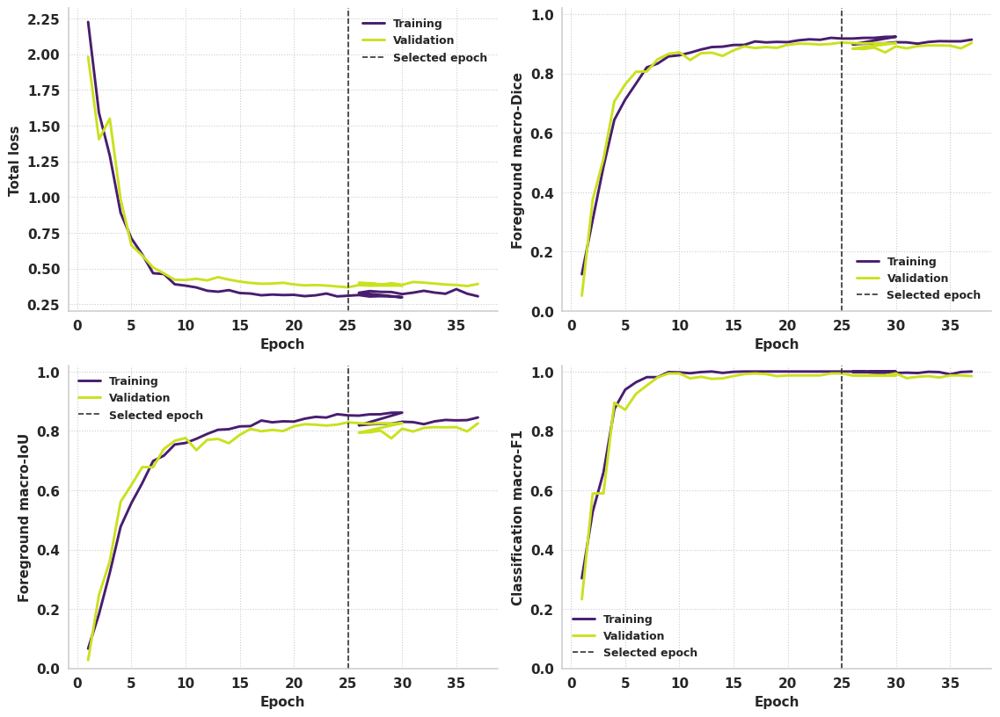

In [ ]:
best_epoch = int(history_df.loc[history_df["selection_score"].idxmax(), "epoch"])
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.3))
panels = [
    ("loss", "Total loss", False),
    ("macro_dice", "Foreground macro-Dice", True),
    ("macro_iou", "Foreground macro-IoU", True),
    ("macro_f1", "Classification macro-F1", True),
]
for ax, (metric, ylabel, bounded) in zip(axes.flat, panels):
    ax.plot(history_df["epoch"], history_df[f"train_{metric}"], lw=2.1, color=PALETTE[0], label="Training")
    ax.plot(history_df["epoch"], history_df[f"valid_{metric}"], lw=2.1, color=PALETTE[5], label="Validation")
    ax.axvline(best_epoch, color="#333333", ls="--", lw=1.2, label="Selected epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    if bounded: ax.set_ylim(0, 1.02)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig03_training_dynamics")
plt.show()


### 6.1 Task-specific losses, selection score, and learning rate

The supplementary optimization panel separates the localization and classification losses, reports the validation selection score used for checkpointing, and records the learning rate actually applied during each epoch.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig03a_task_losses_selection_and_lr.png


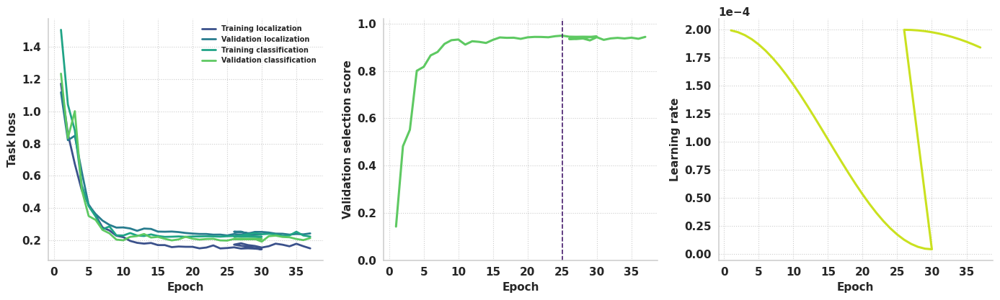

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.3))
axes[0].plot(history_df["epoch"], history_df["train_seg_loss"], color=PALETTE[1], lw=2.0, label="Training localization")
axes[0].plot(history_df["epoch"], history_df["valid_seg_loss"], color=PALETTE[2], lw=2.0, label="Validation localization")
axes[0].plot(history_df["epoch"], history_df["train_cls_loss"], color=PALETTE[3], lw=2.0, label="Training classification")
axes[0].plot(history_df["epoch"], history_df["valid_cls_loss"], color=PALETTE[4], lw=2.0, label="Validation classification")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Task loss")
axes[0].legend(fontsize=7)

axes[1].plot(history_df["epoch"], history_df["selection_score"], color=PALETTE[4], lw=2.2)
axes[1].axvline(best_epoch, color=PALETTE[0], ls="--", lw=1.2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation selection score")
axes[1].set_ylim(0, 1.02)

axes[2].plot(history_df["epoch"], history_df["lr"], color=PALETTE[5], lw=2.2)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning rate")
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
for ax in axes: sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig03a_task_losses_selection_and_lr")
plt.show()


## 7. Frozen-test inference and numerical results

The test set is evaluated once after restoring the validation-selected checkpoint. Predictions, probabilities, segmentation confusion counts, image identifiers, and confidence maps are retained for subsequent plots so every figure is based on the same inference pass.


In [ ]:
@torch.no_grad()
def collect_predictions(loader):
    model.eval()
    seg_cm = np.zeros((NUM_MASK_CLASSES, NUM_MASK_CLASSES), dtype=np.int64)
    y_true, probs_all, names = [], [], []
    qualitative = []
    for batch in tqdm(loader, desc="Frozen-test inference"):
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)
        labels = batch["label"].to(device)
        valid = batch["class_valid"].to(device)
        outputs = model(images)
        seg_probs = torch.softmax(outputs["seg_logits"], dim=1)
        seg_entropy = -(seg_probs * torch.log(seg_probs.clamp_min(1e-8))).sum(dim=1) / math.log(NUM_MASK_CLASSES)
        seg_pred = seg_probs.argmax(1)
        update_seg_confusion(seg_cm, masks, seg_pred)
        cls_probs = torch.softmax(outputs["cls_logits"], dim=1)
        if valid.any():
            y_true.extend(labels[valid].cpu().tolist())
            probs_all.append(cls_probs[valid].cpu().numpy())
            names.extend(np.asarray(batch["file_name"])[valid.cpu().numpy()].tolist())
        for i in range(images.size(0)):
            qualitative.append({
                "image": images[i].cpu(), "mask": masks[i].cpu(),
                "pred": seg_pred[i].cpu(), "confidence": seg_probs[i].max(0).values.cpu(),
                "entropy": seg_entropy[i].cpu(),
                "foreground": outputs["foreground"][i, 0].cpu(),
                "label": int(labels[i].cpu()), "class_valid": bool(valid[i].cpu()),
                "cls_prob": cls_probs[i].cpu(), "file_name": batch["file_name"][i]
            })
    return np.asarray(y_true), np.concatenate(probs_all), seg_cm, qualitative, names

y_true, y_prob, seg_cm, qualitative, evaluated_names = collect_predictions(test_loader)
y_pred = y_prob.argmax(axis=1)


Frozen-test inference:   0%|          | 0/19 [00:00<?, ?it/s]

In [ ]:
def classification_summary(y_true, y_pred, y_prob):
    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0
    )
    specificity = []
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
    for c in range(NUM_CLASSES):
        tp, fn = cm[c, c], cm[c].sum() - cm[c, c]
        fp = cm[:, c].sum() - tp
        tn = cm.sum() - tp - fn - fp
        specificity.append(tn / max(tn + fp, 1))
    y_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
    aucs, aps = [], []
    for c in range(NUM_CLASSES):
        aucs.append(roc_auc_score(y_bin[:, c], y_prob[:, c]) if len(np.unique(y_bin[:, c])) == 2 else np.nan)
        aps.append(average_precision_score(y_bin[:, c], y_prob[:, c]) if y_bin[:, c].sum() else np.nan)
    per_class = pd.DataFrame({
        "Class": class_names, "Precision": p, "Recall": r, "Specificity": specificity,
        "F1-score": f1, "ROC-AUC": aucs, "Average precision": aps, "Support": support
    })
    overall = pd.DataFrame([{
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro-F1": f1.mean(),
        "Weighted-F1": np.average(f1, weights=support),
        "Macro ROC-AUC OvR": roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr"),
        "Macro average precision": np.nanmean(aps),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen kappa": cohen_kappa_score(y_true, y_pred),
        "Log loss": log_loss(y_true, y_prob, labels=np.arange(NUM_CLASSES)),
    }])
    return per_class, overall, cm

def segmentation_summary(cm):
    dice, iou = metrics_from_seg_cm(cm)
    recall = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
    precision = np.diag(cm) / np.maximum(cm.sum(axis=0), 1)
    table = pd.DataFrame({"Class": mask_names, "Dice": dice, "IoU": iou, "Precision": precision, "Recall": recall})
    macro = pd.DataFrame([{
        "Task interpretation": TASK_NAME,
        "Foreground macro-Dice": dice[1:].mean(),
        "Foreground macro-IoU": iou[1:].mean(),
        "Mean pixel accuracy": recall.mean(),
    }])
    return table, macro

cls_table, cls_overall, cls_cm = classification_summary(y_true, y_pred, y_prob)
seg_table, seg_overall = segmentation_summary(seg_cm)
display(cls_overall.style.format("{:.4f}"))
display(cls_table.style.format({c: "{:.4f}" for c in cls_table.columns if c not in ("Class", "Support")}))
display(seg_overall.style.format({c: "{:.4f}" for c in seg_overall.columns if c != "Task interpretation"}))
display(seg_table.style.format({c: "{:.4f}" for c in seg_table.columns if c != "Class"}))

cls_overall.to_csv(TABLE_DIR / "classification_overall.csv", index=False)
cls_table.to_csv(TABLE_DIR / "classification_per_class.csv", index=False)
seg_overall.to_csv(TABLE_DIR / "localization_overall.csv", index=False)
seg_table.to_csv(TABLE_DIR / "localization_per_class.csv", index=False)
pd.DataFrame(y_prob, columns=[f"prob_{c}" for c in class_names]).assign(
    file_name=evaluated_names, true_label=y_true, predicted_label=y_pred
).to_csv(TABLE_DIR / "frozen_test_predictions.csv", index=False)


,Accuracy,Balanced accuracy,Macro-F1,Weighted-F1,Macro ROC-AUC OvR,Macro average precision,MCC,Cohen kappa,Log loss
0,0.9934,0.9867,0.9904,0.9933,0.9989,0.9944,0.9909,0.9909,0.0687


,Class,Precision,Recall,Specificity,F1-score,ROC-AUC,Average precision,Support
0,Astrovirus,0.9730,1.0000,0.9913,0.9863,0.9981,0.9933,36
1,Cryptosporidium,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,55
2,Giardia,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,41
3,Norovirus,1.0000,0.9333,1.0000,0.9655,0.9966,0.9788,15
4,Rotavirus,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,4


,Task interpretation,Foreground macro-Dice,Foreground macro-IoU,Mean pixel accuracy
0,segmentation,0.8939,0.8140,0.9448


,Class,Dice,IoU,Precision,Recall
0,Background,0.9845,0.9694,0.9932,0.9759
1,Astrovirus,0.8998,0.8178,0.9108,0.8890
2,Cryptosporidium,0.9178,0.8480,0.8624,0.9807
3,Giardia,0.9073,0.8303,0.8702,0.9477
4,Norovirus,0.7744,0.6319,0.6886,0.8846
5,Rotavirus,0.9701,0.9419,0.9501,0.9908


## 8. Bootstrap confidence intervals

The bootstrap resamples test images rather than pixels. This avoids treating correlated pixels from the same image as independent observations. Intervals are descriptive uncertainty estimates and do not replace an external test cohort.


In [ ]:
def stratified_bootstrap_ci(y_true, y_pred, y_prob, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    class_indices = [np.where(y_true == c)[0] for c in range(NUM_CLASSES)]
    rows = []
    for _ in tqdm(range(n_boot), desc="Bootstrap"):
        idx = np.concatenate([rng.choice(ids, size=len(ids), replace=True) for ids in class_indices if len(ids)])
        yt, yp, pr = y_true[idx], y_pred[idx], y_prob[idx]
        yb = label_binarize(yt, classes=np.arange(NUM_CLASSES))
        rows.append({
            "Accuracy": accuracy_score(yt, yp),
            "Macro-F1": precision_recall_fscore_support(yt, yp, labels=np.arange(NUM_CLASSES), average="macro", zero_division=0)[2],
            "Macro ROC-AUC": roc_auc_score(yb, pr, average="macro", multi_class="ovr"),
            "MCC": matthews_corrcoef(yt, yp),
        })
    boot = pd.DataFrame(rows)
    ci = pd.DataFrame({
        "Metric": boot.columns,
        "Estimate": [cls_overall.iloc[0].get(c, np.nan) if c != "Macro ROC-AUC" else cls_overall.iloc[0]["Macro ROC-AUC OvR"] for c in boot.columns],
        "CI 2.5%": boot.quantile(0.025).values,
        "CI 97.5%": boot.quantile(0.975).values,
    })
    return ci, boot

bootstrap_ci, bootstrap_samples = stratified_bootstrap_ci(y_true, y_pred, y_prob)
display(bootstrap_ci.style.format({"Estimate": "{:.4f}", "CI 2.5%": "{:.4f}", "CI 97.5%": "{:.4f}"}))
bootstrap_ci.to_csv(TABLE_DIR / "classification_bootstrap_95ci.csv", index=False)


Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

,Metric,Estimate,CI 2.5%,CI 97.5%
0,Accuracy,0.9934,0.9801,1.0000
1,Macro-F1,0.9904,0.9698,1.0000
2,Macro ROC-AUC,0.9989,0.9962,1.0000
3,MCC,0.9909,0.9731,1.0000


## 9. Confusion matrices

Counts show the absolute error burden, whereas row-normalized values show recall by class. The localization matrix is restricted to foreground classes in its main panel so the large background region does not conceal pathogen-class errors.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig04_classification_confusion_matrices.png


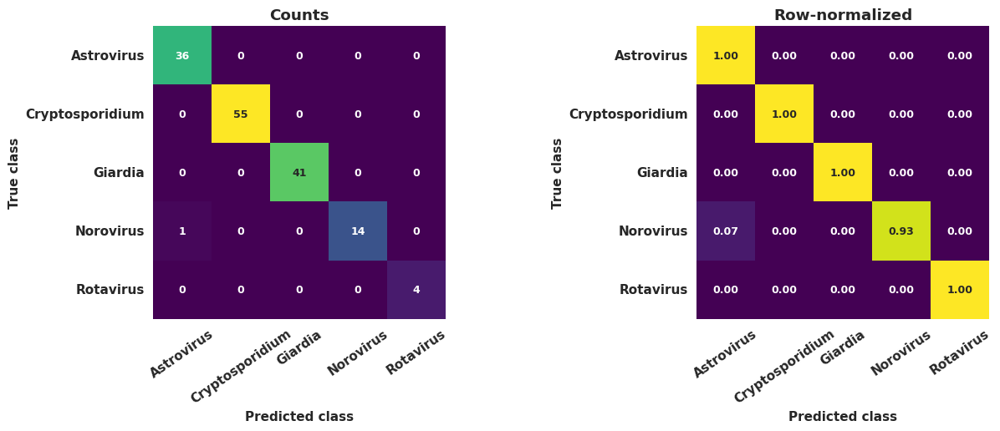

Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig05_localization_foreground_confusion.png


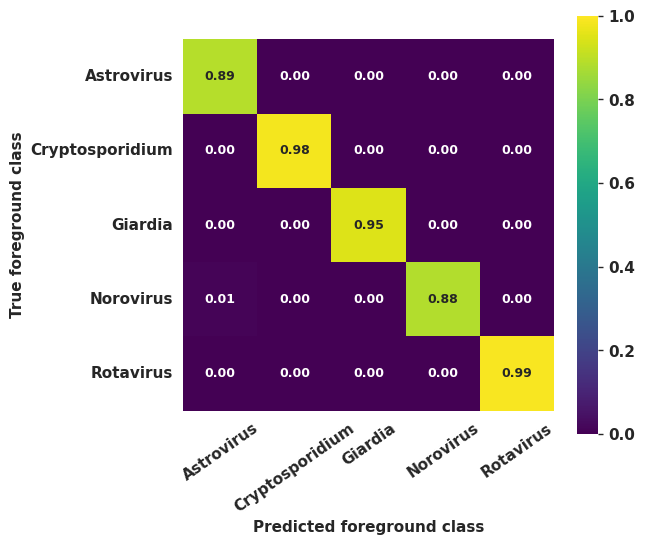

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.3))
for ax, matrix, title, fmt in [
    (axes[0], cls_cm, "Counts", "d"),
    (axes[1], cls_cm / np.maximum(cls_cm.sum(axis=1, keepdims=True), 1), "Row-normalized", ".2f"),
]:
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap="viridis", cbar=False, square=True,
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                annot_kws={"fontsize": 9, "fontweight": "bold"})
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
save_figure(fig, "fig04_classification_confusion_matrices")
plt.show()

fg_cm = seg_cm[1:, 1:]
fg_norm = fg_cm / np.maximum(seg_cm[1:, :].sum(axis=1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(6.7, 5.7))
sns.heatmap(fg_norm, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, square=True,
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            annot_kws={"fontsize": 9, "fontweight": "bold"})
ax.set_xlabel("Predicted foreground class")
ax.set_ylabel("True foreground class")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
save_figure(fig, "fig05_localization_foreground_confusion")
plt.show()


## 10. ROC and precision-recall analysis


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig06_roc_precision_recall.png


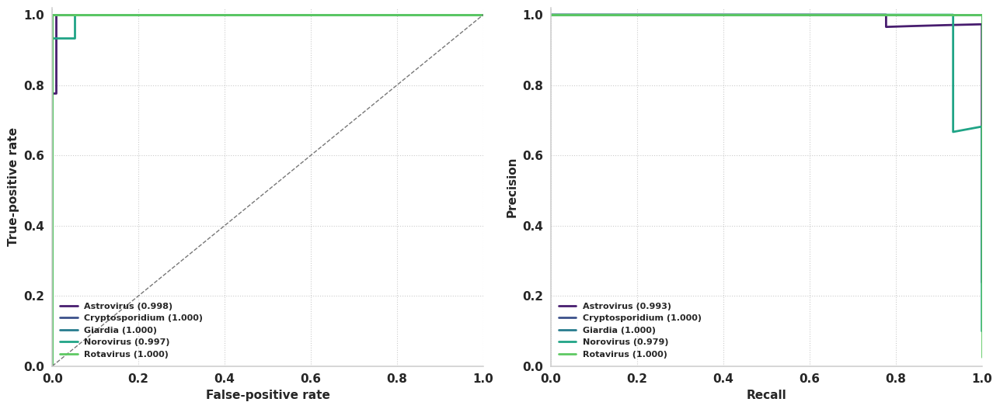

In [ ]:
y_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4))
for c, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, c], y_prob[:, c])
    precision, recall, _ = precision_recall_curve(y_bin[:, c], y_prob[:, c])
    auc = roc_auc_score(y_bin[:, c], y_prob[:, c])
    ap = average_precision_score(y_bin[:, c], y_prob[:, c])
    axes[0].plot(fpr, tpr, lw=2, color=PALETTE[c % len(PALETTE)], label=f"{name} ({auc:.3f})")
    axes[1].plot(recall, precision, lw=2, color=PALETTE[c % len(PALETTE)], label=f"{name} ({ap:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="#777777", lw=1)
axes[0].set(xlabel="False-positive rate", ylabel="True-positive rate", xlim=(0, 1), ylim=(0, 1.02))
axes[1].set(xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1.02))
for ax in axes:
    ax.legend(fontsize=8, loc="lower left")
    sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig06_roc_precision_recall")
plt.show()


## 11. Calibration and selective prediction

The reliability diagram compares mean confidence with empirical accuracy. The risk-coverage curve shows how the error rate changes when low-confidence cases are withheld for review. These plots complement discrimination metrics without implying clinical or operational readiness.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig07_calibration_selective_risk.png


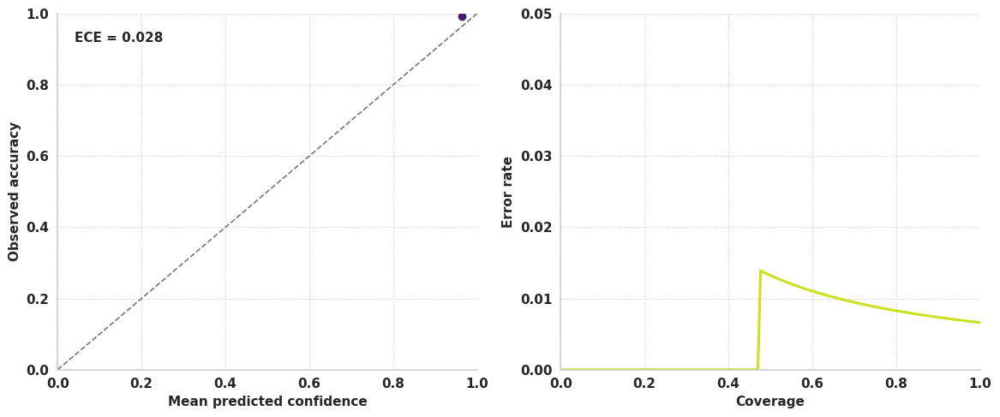

In [ ]:
def calibration_statistics(y_true, y_prob, n_bins=10):
    confidence = y_prob.max(axis=1)
    prediction = y_prob.argmax(axis=1)
    correct = (prediction == y_true).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    rows, ece = [], 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        include = (confidence > lo) & (confidence <= hi) if lo > 0 else (confidence >= lo) & (confidence <= hi)
        if include.any():
            acc, conf, n = correct[include].mean(), confidence[include].mean(), include.sum()
            ece += (n / len(y_true)) * abs(acc - conf)
            rows.append({"Lower": lo, "Upper": hi, "Mean confidence": conf, "Accuracy": acc, "Count": n})
    return pd.DataFrame(rows), ece

calibration_df, ece = calibration_statistics(y_true, y_prob)
order = np.argsort(-y_prob.max(axis=1))
correct_ordered = (y_pred[order] == y_true[order]).astype(float)
coverage = np.arange(1, len(order) + 1) / len(order)
risk = 1.0 - np.cumsum(correct_ordered) / np.arange(1, len(order) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.0))
axes[0].plot([0, 1], [0, 1], "--", color="#777777", lw=1.2)
axes[0].plot(calibration_df["Mean confidence"], calibration_df["Accuracy"], "o-", color=PALETTE[0], lw=2.2)
axes[0].set(xlabel="Mean predicted confidence", ylabel="Observed accuracy", xlim=(0, 1), ylim=(0, 1))
axes[0].text(0.04, 0.92, f"ECE = {ece:.3f}", transform=axes[0].transAxes, fontweight="bold")
axes[1].plot(coverage, risk, color=PALETTE[5], lw=2.2)
axes[1].set(xlabel="Coverage", ylabel="Error rate", xlim=(0, 1), ylim=(0, max(0.05, risk.max() * 1.08)))
for ax in axes: sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig07_calibration_selective_risk")
plt.show()
calibration_df.to_csv(TABLE_DIR / "calibration_bins.csv", index=False)


## 12. Per-class performance profile


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig08_classwise_classification_metrics.png


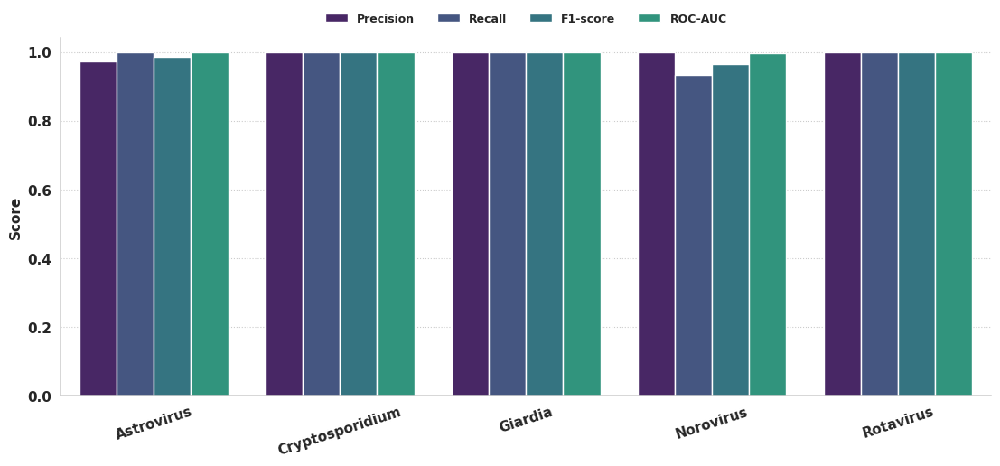

Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig09_classwise_localization_metrics.png


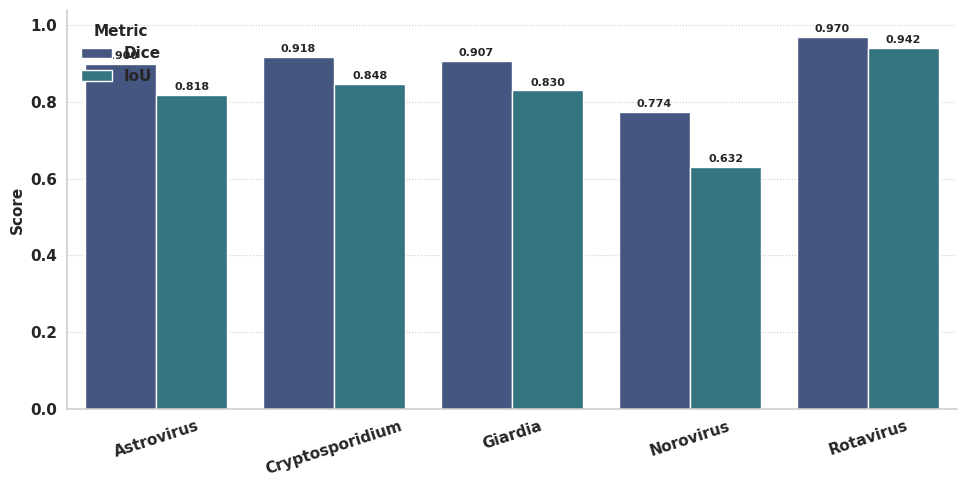

In [ ]:
plot_df = cls_table.melt(
    id_vars="Class", value_vars=["Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metric", value_name="Score"
)
fig, ax = plt.subplots(figsize=(11.2, 5.3))
sns.barplot(data=plot_df, x="Class", y="Score", hue="Metric", palette=PALETTE[:4], ax=ax)
ax.set_ylim(0, 1.04)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=18)
ax.legend(ncol=4, loc="lower center", bbox_to_anchor=(0.5, 1.01), fontsize=9)
sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig08_classwise_classification_metrics")
plt.show()

loc_plot = seg_table.iloc[1:].melt(id_vars="Class", value_vars=["Dice", "IoU"], var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(9.8, 5.0))
sns.barplot(data=loc_plot, x="Class", y="Score", hue="Metric", palette=[PALETTE[1], PALETTE[2]], ax=ax)
ax.set_ylim(0, 1.04)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=18)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8, fontweight="bold")
sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig09_classwise_localization_metrics")
plt.show()


## 13. Qualitative localization, confidence, and error maps

Examples are selected deterministically across pathogen classes. The error panel separates false-negative pixels from false-positive pixels. For box-only datasets, boundaries correspond to reference rectangles and must not be interpreted as organism contours.


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig10_qualitative_multitask_examples.png


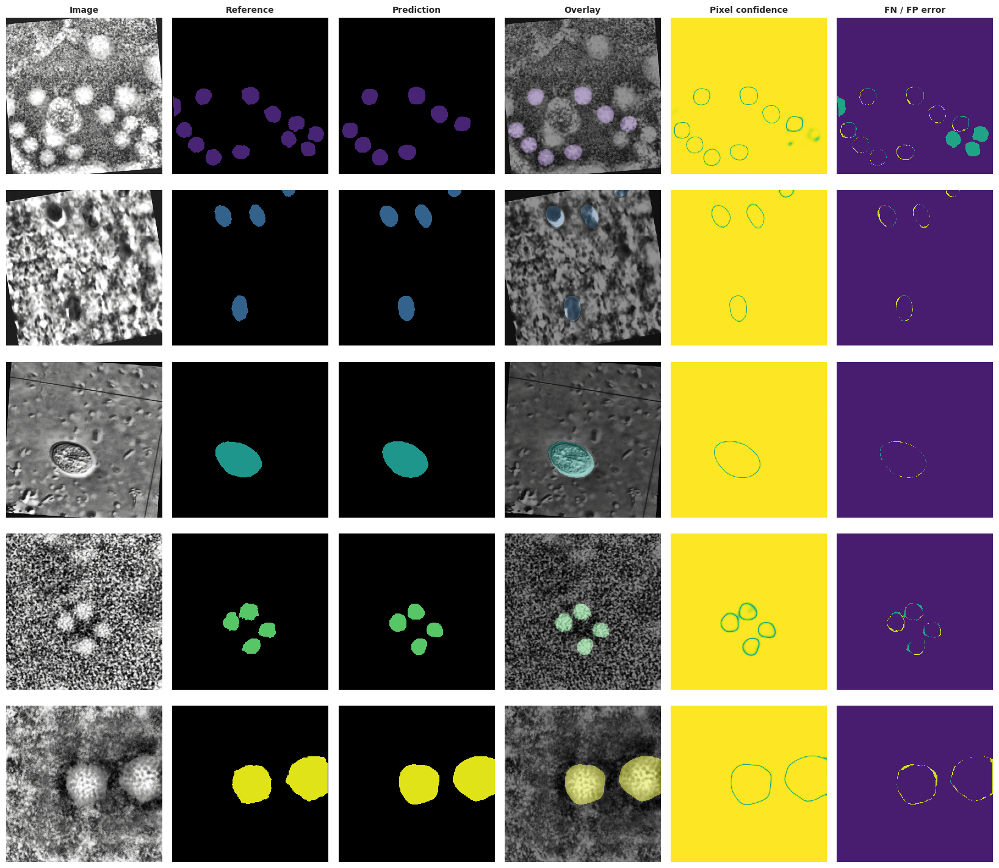

In [ ]:
def binary_dice(gt, pred, eps=1e-6):
    gt, pred = gt > 0, pred > 0
    return float((2 * np.logical_and(gt, pred).sum() + eps) / (gt.sum() + pred.sum() + eps))

for item in qualitative:
    item["sample_dice"] = binary_dice(item["mask"].numpy(), item["pred"].numpy())

selected = []
for label in range(NUM_CLASSES):
    candidates = [i for i, q in enumerate(qualitative) if q["class_valid"] and q["label"] == label]
    if candidates:
        candidates.sort(key=lambda i: abs(qualitative[i]["sample_dice"] - np.median([qualitative[j]["sample_dice"] for j in candidates])))
        selected.append(candidates[0])

fig, axes = plt.subplots(len(selected), 6, figsize=(16.5, 2.9 * len(selected)))
if len(selected) == 1: axes = axes[None, :]
for row, idx in enumerate(selected):
    q = qualitative[idx]
    image = denormalize(q["image"])
    gt, pred = q["mask"].numpy(), q["pred"].numpy()
    error = np.zeros_like(gt, dtype=np.uint8)
    error[(gt > 0) & (pred == 0)] = 1
    error[(gt == 0) & (pred > 0)] = 2
    cls_id = int(q["cls_prob"].argmax())
    panels = [image, gt, pred, image, q["confidence"].numpy(), error]
    cmaps = [None, mask_cmap, mask_cmap, None, "viridis", mpl.colors.ListedColormap([PALETTE[0], PALETTE[3], PALETTE[5]])]
    norms = [None, mask_norm, mask_norm, None, mpl.colors.Normalize(0, 1), mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3)]
    titles = ["Image", "Reference", "Prediction", "Overlay", "Pixel confidence", "FN / FP error"]
    for col in range(6):
        axes[row, col].imshow(panels[col], cmap=cmaps[col], norm=norms[col], interpolation="nearest")
        if col == 3:
            axes[row, col].imshow(pred, cmap=mask_cmap, norm=mask_norm, alpha=0.43, interpolation="nearest")
        axes[row, col].axis("off")
        if row == 0: axes[row, col].set_title(titles[col], fontsize=10)
    axes[row, 0].set_ylabel(
        f"True: {class_names[q['label']]}\nPred: {class_names[cls_id]} ({q['cls_prob'][cls_id]:.2f})\nDice: {q['sample_dice']:.3f}",
        fontsize=9, fontweight="bold"
    )
fig.tight_layout()
save_figure(fig, "fig10_qualitative_multitask_examples")
plt.show()


### 13.1 Localization confidence, entropy, and foreground probability

Maximum softmax confidence and normalized predictive entropy are displayed beside the foreground probability map. Low confidence and high entropy indicate uncertain pixels but do not by themselves establish annotation error or model failure.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig10a_localization_uncertainty_maps.png


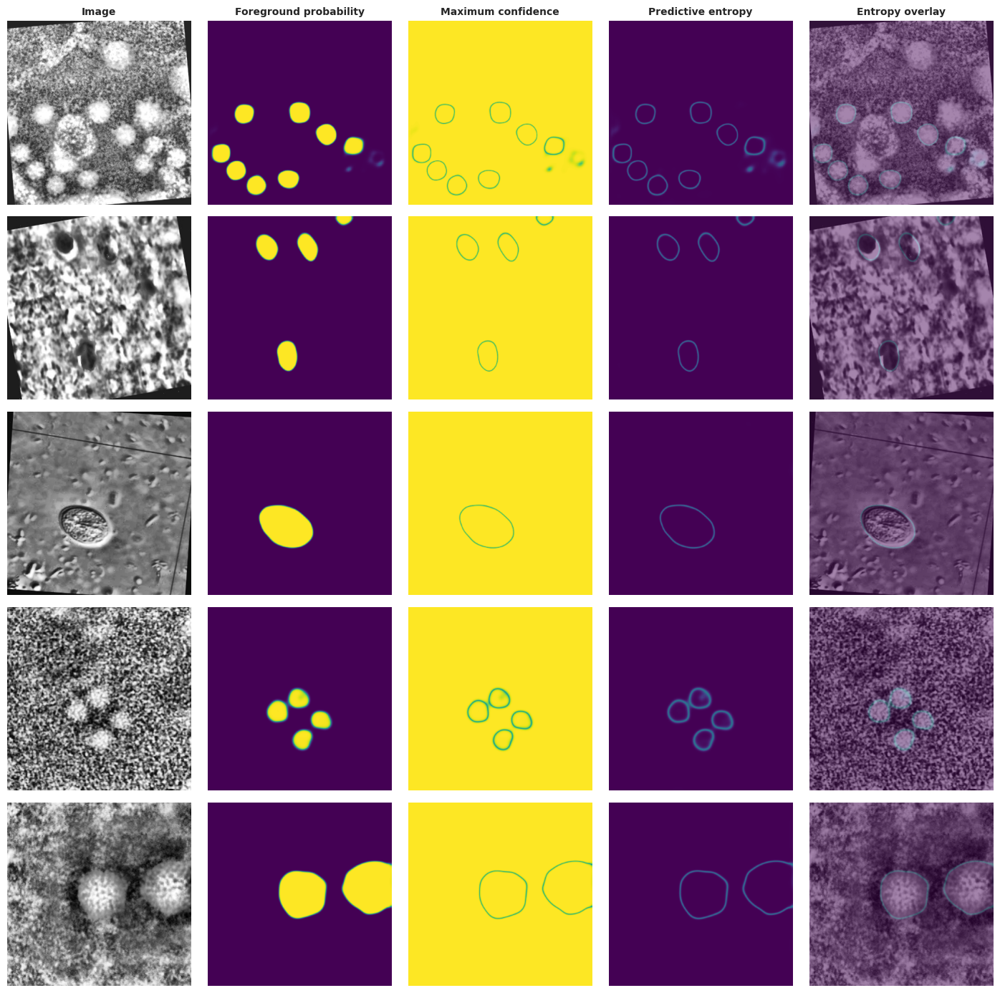

In [ ]:
fig, axes = plt.subplots(len(selected), 5, figsize=(14.2, 2.8 * len(selected)))
if len(selected) == 1: axes = axes[None, :]
for row, idx in enumerate(selected):
    q = qualitative[idx]
    image = denormalize(q["image"])
    maps = [image, q["foreground"].numpy(), q["confidence"].numpy(), q["entropy"].numpy(), image]
    cmaps = [None, "viridis", "viridis", "viridis", None]
    for col, (panel, cmap_name) in enumerate(zip(maps, cmaps)):
        axes[row, col].imshow(panel, cmap=cmap_name, vmin=0 if cmap_name else None, vmax=1 if cmap_name else None)
        axes[row, col].axis("off")
    axes[row, 4].imshow(q["entropy"].numpy(), cmap="viridis", alpha=0.48, vmin=0, vmax=1)
    axes[row, 0].set_ylabel(class_names[q["label"]] if q["class_valid"] else "Multi-class",
                            fontsize=9, fontweight="bold")
for col, label in enumerate(["Image", "Foreground probability", "Maximum confidence", "Predictive entropy", "Entropy overlay"]):
    axes[0, col].set_title(label, fontsize=10)
fig.tight_layout()
save_figure(fig, "fig10a_localization_uncertainty_maps")
plt.show()


### 13.2 Class-probability profiles

One representative sample from each available test class is shown with its complete predicted probability vector. The figure exposes secondary predictions that are not visible when only the winning class is displayed.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig10b_class_probability_profiles.png


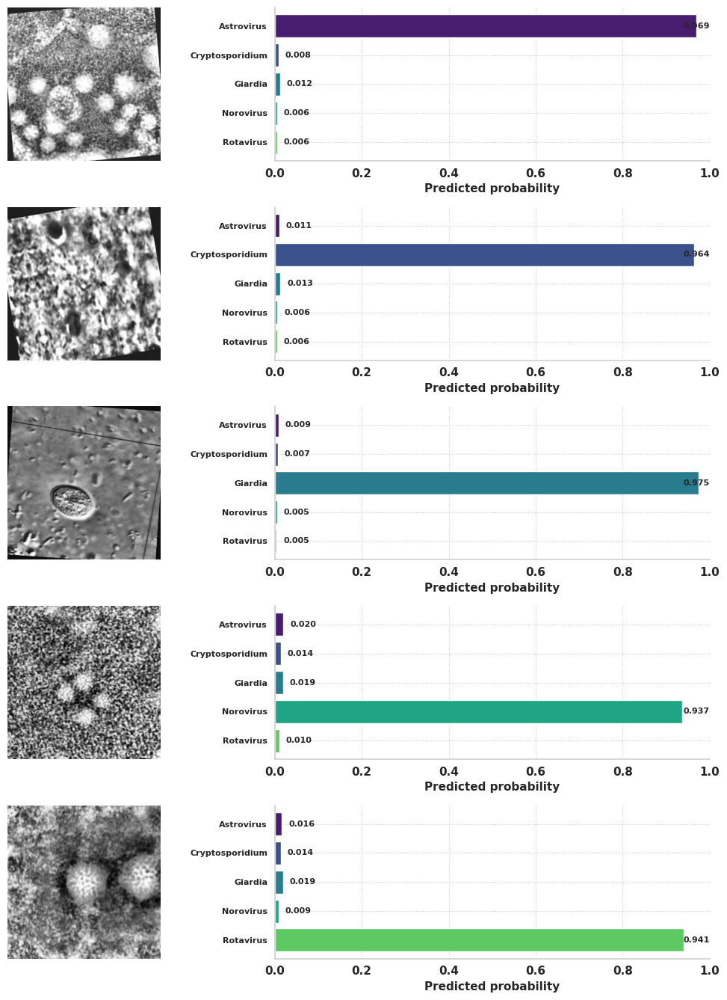

In [ ]:
fig, axes = plt.subplots(len(selected), 2, figsize=(10.6, 2.7 * len(selected)),
                         gridspec_kw={"width_ratios": [1.0, 1.65]})
if len(selected) == 1: axes = axes[None, :]
for row, idx in enumerate(selected):
    q = qualitative[idx]
    probabilities = q["cls_prob"].numpy()
    prediction = int(probabilities.argmax())
    axes[row, 0].imshow(denormalize(q["image"]))
    axes[row, 0].set_ylabel(f"True: {class_names[q['label']]}\nPred: {class_names[prediction]}",
                            fontsize=9, fontweight="bold")
    axes[row, 0].axis("off")
    axes[row, 1].barh(np.arange(NUM_CLASSES), probabilities, color=PALETTE[:NUM_CLASSES])
    axes[row, 1].set_yticks(np.arange(NUM_CLASSES), class_names, fontsize=8)
    axes[row, 1].set_xlim(0, 1.0)
    axes[row, 1].set_xlabel("Predicted probability")
    axes[row, 1].invert_yaxis()
    for y, value in enumerate(probabilities):
        axes[row, 1].text(min(value + 0.015, 0.94), y, f"{value:.3f}", va="center", fontsize=8, fontweight="bold")
    sns.despine(ax=axes[row, 1])
fig.tight_layout()
save_figure(fig, "fig10b_class_probability_profiles")
plt.show()


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig10b_segmentation_and_class_probability_profiles.png


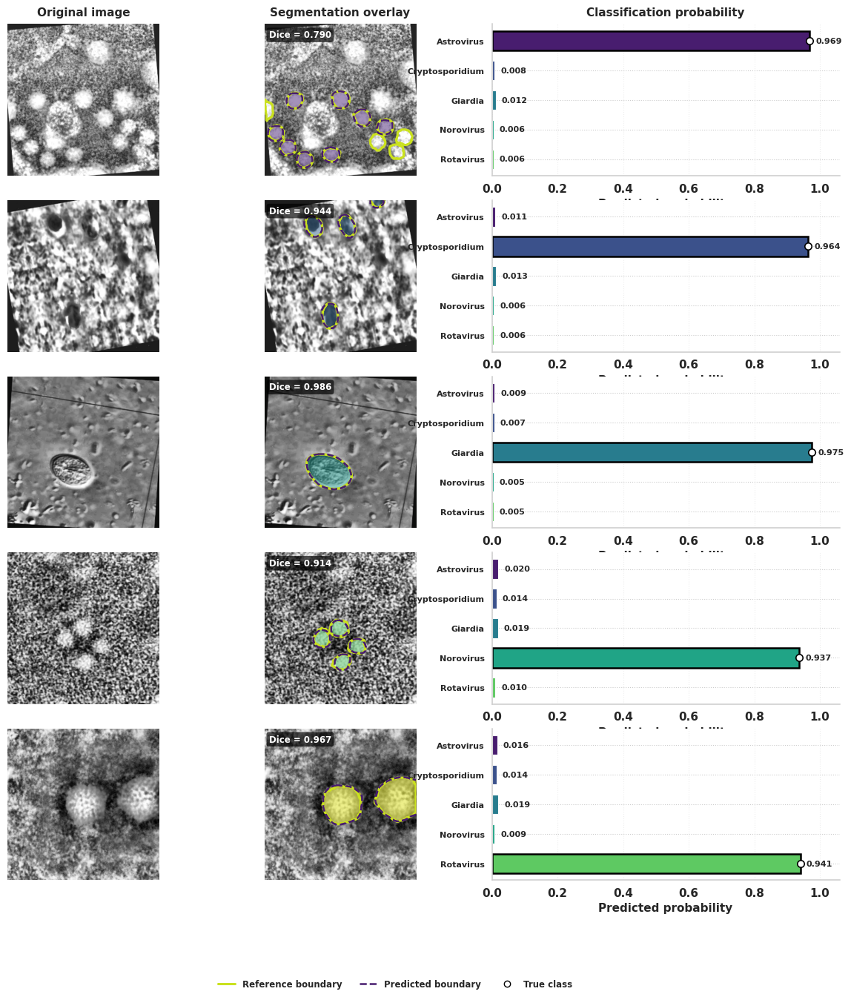

In [ ]:
fig, axes = plt.subplots(
    len(selected), 3,
    figsize=(15.0, 3.0 * len(selected)),
    gridspec_kw={
        "width_ratios": [1.0, 1.0, 1.65],
        "wspace": 0.18,
        "hspace": 0.16
    }
)

if len(selected) == 1:
    axes = axes[None, :]

reference_color = PALETTE[5]
prediction_color = PALETTE[0]

for row, idx in enumerate(selected):

    q = qualitative[idx]

    image = denormalize(q["image"])
    ground_truth = q["mask"].numpy()
    predicted_mask = q["pred"].numpy()

    probabilities = q["cls_prob"].numpy()
    true_class = int(q["label"])
    prediction = int(probabilities.argmax())

    # Calculate foreground Dice for the displayed sample
    gt_binary = ground_truth > 0
    pred_binary = predicted_mask > 0

    intersection = np.logical_and(gt_binary, pred_binary).sum()

    sample_dice = (
        2.0 * intersection + 1e-6
    ) / (
        gt_binary.sum() + pred_binary.sum() + 1e-6
    )

    # Panel 1: Original image
    axes[row, 0].imshow(image)

    axes[row, 0].set_ylabel(
        f"True: {class_names[true_class]}\n"
        f"Pred: {class_names[prediction]} "
        f"({probabilities[prediction]:.3f})",
        fontsize=9,
        fontweight="bold",
        labelpad=8
    )

    axes[row, 0].axis("off")

    # Panel 2: Predicted segmentation overlay
    axes[row, 1].imshow(image)

    visible_prediction = np.ma.masked_where(
        predicted_mask == 0,
        predicted_mask
    )

    axes[row, 1].imshow(
        visible_prediction,
        cmap=mask_cmap,
        norm=mask_norm,
        alpha=0.50,
        interpolation="nearest"
    )

    # Ground-truth boundary
    if gt_binary.any() and (~gt_binary).any():
        axes[row, 1].contour(
            gt_binary,
            levels=[0.5],
            colors=[reference_color],
            linewidths=2.2
        )

    # Predicted boundary
    if pred_binary.any() and (~pred_binary).any():
        axes[row, 1].contour(
            pred_binary,
            levels=[0.5],
            colors=[prediction_color],
            linewidths=1.8,
            linestyles="--"
        )

    axes[row, 1].text(
        0.03,
        0.96,
        f"Dice = {sample_dice:.3f}",
        transform=axes[row, 1].transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        fontweight="bold",
        color="white",
        bbox={
            "boxstyle": "round,pad=0.28",
            "facecolor": "black",
            "edgecolor": "none",
            "alpha": 0.68
        }
    )

    axes[row, 1].axis("off")

    # Panel 3: Classification probability profile
    y_positions = np.arange(NUM_CLASSES)

    class_colors = [
        PALETTE[i % len(PALETTE)]
        for i in range(NUM_CLASSES)
    ]

    bars = axes[row, 2].barh(
        y_positions,
        probabilities,
        height=0.66,
        color=class_colors,
        edgecolor="white",
        linewidth=0.8
    )

    # Highlight predicted class
    bars[prediction].set_edgecolor("black")
    bars[prediction].set_linewidth(1.8)

    # Mark true class
    axes[row, 2].scatter(
        probabilities[true_class],
        true_class,
        s=46,
        marker="o",
        facecolor="white",
        edgecolor="black",
        linewidth=1.2,
        zorder=5
    )

    axes[row, 2].set_yticks(
        y_positions,
        class_names,
        fontsize=8,
        fontweight="bold"
    )

    axes[row, 2].set_xlim(0, 1.06)
    axes[row, 2].set_xticks(np.linspace(0, 1, 6))
    axes[row, 2].set_xlabel(
        "Predicted probability",
        fontweight="bold"
    )

    axes[row, 2].invert_yaxis()
    axes[row, 2].grid(
        axis="x",
        linestyle=":",
        linewidth=0.8,
        alpha=0.35
    )

    for y, value in enumerate(probabilities):
        axes[row, 2].text(
            min(value + 0.018, 1.015),
            y,
            f"{value:.3f}",
            va="center",
            fontsize=8,
            fontweight="bold"
        )

    sns.despine(ax=axes[row, 2])

axes[0, 0].set_title(
    "Original image",
    fontsize=11,
    fontweight="bold",
    pad=8
)

axes[0, 1].set_title(
    "Segmentation overlay",
    fontsize=11,
    fontweight="bold",
    pad=8
)

axes[0, 2].set_title(
    "Classification probability",
    fontsize=11,
    fontweight="bold",
    pad=8
)

legend_handles = [
    mpl.lines.Line2D(
        [0], [0],
        color=reference_color,
        linewidth=2.2,
        label="Reference boundary"
    ),
    mpl.lines.Line2D(
        [0], [0],
        color=prediction_color,
        linewidth=1.8,
        linestyle="--",
        label="Predicted boundary"
    ),
    mpl.lines.Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=6,
        label="True class"
    )
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    ncol=3,
    fontsize=8.5,
    frameon=False
)

fig.tight_layout(rect=[0, 0.045, 1, 1])

save_figure(
    fig,
    "fig10b_segmentation_and_class_probability_profiles"
)

plt.show()

### 13.3 Class-wise localization gallery

For each pathogen class, three test cases are selected across the observed per-image Dice range. Displaying lower-, middle-, and higher-overlap examples reduces favorable-case selection in the qualitative analysis.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig10c_classwise_localization_gallery.png


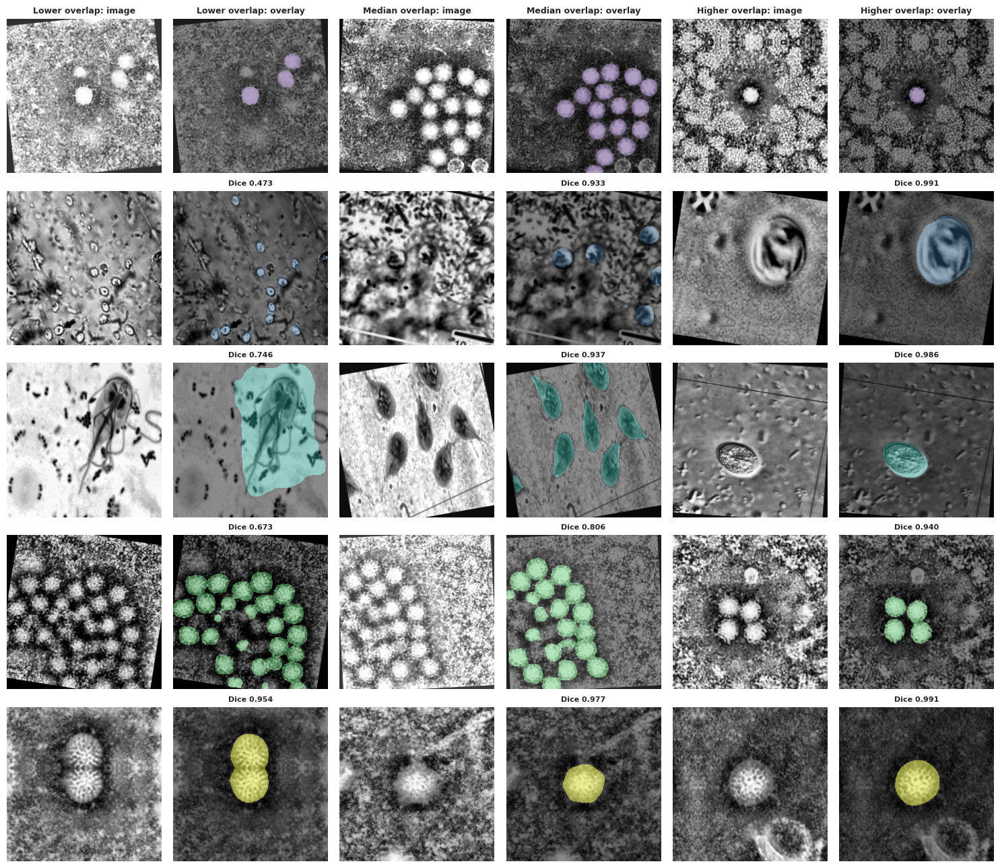

In [ ]:
gallery_rows = []
for label in range(NUM_CLASSES):
    candidates = [i for i, q in enumerate(qualitative) if q["class_valid"] and q["label"] == label]
    candidates = sorted(candidates, key=lambda i: qualitative[i]["sample_dice"])
    if candidates:
        positions = np.linspace(0, len(candidates) - 1, 3).round().astype(int)
        gallery_rows.append((label, [candidates[p] for p in positions]))

fig, axes = plt.subplots(len(gallery_rows), 6, figsize=(15.0, 2.6 * len(gallery_rows)))
if len(gallery_rows) == 1: axes = axes[None, :]
for row, (label, indices) in enumerate(gallery_rows):
    for group, idx in enumerate(indices):
        q = qualitative[idx]
        image, pred = denormalize(q["image"]), q["pred"].numpy()
        axes[row, 2 * group].imshow(image)
        axes[row, 2 * group + 1].imshow(image)
        axes[row, 2 * group + 1].imshow(pred, cmap=mask_cmap, norm=mask_norm, alpha=0.44, interpolation="nearest")
        axes[row, 2 * group + 1].set_title(f"Dice {q['sample_dice']:.3f}", fontsize=8)
    axes[row, 0].set_ylabel(class_names[label], fontsize=9, fontweight="bold")
    for ax in axes[row]: ax.axis("off")
for group, label in enumerate(["Lower overlap", "Median overlap", "Higher overlap"]):
    axes[0, 2 * group].set_title(f"{label}: image", fontsize=9)
    axes[0, 2 * group + 1].set_title(f"{label}: overlay", fontsize=9)
fig.tight_layout()
save_figure(fig, "fig10c_classwise_localization_gallery")
plt.show()


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig10c_classwise_localization_gallery.png


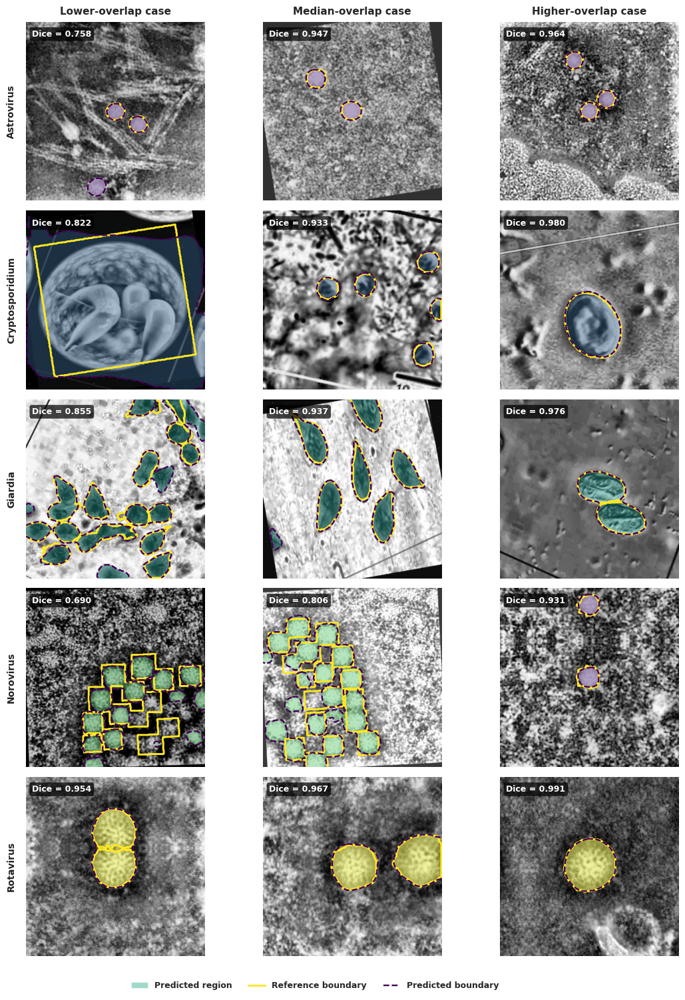

In [ ]:
gallery_rows = []

# Select samples near the 10th, 50th, and 90th Dice percentiles
# within each class instead of using only the absolute extremes.
target_quantiles = [0.10, 0.50, 0.90]

for label in range(NUM_CLASSES):

    candidates = [
        i for i, q in enumerate(qualitative)
        if q["class_valid"] and q["label"] == label
    ]

    if not candidates:
        continue

    scores = np.array([
        qualitative[i]["sample_dice"]
        for i in candidates
    ])

    selected_indices = []

    for quantile in target_quantiles:

        target_score = np.quantile(scores, quantile)

        selected_position = int(
            np.argmin(np.abs(scores - target_score))
        )

        selected_indices.append(
            candidates[selected_position]
        )

    gallery_rows.append(
        (label, selected_indices)
    )

if not gallery_rows:
    raise RuntimeError(
        "No valid class-wise localization samples were found."
    )

# Three-column layout:
# each panel contains the source image and segmentation overlay.
fig, axes = plt.subplots(
    len(gallery_rows),
    3,
    figsize=(11.8, 3.05 * len(gallery_rows)),
    gridspec_kw={
        "wspace": 0.035,
        "hspace": 0.055
    }
)

if len(gallery_rows) == 1:
    axes = axes[None, :]

case_titles = [
    "Lower-overlap case",
    "Median-overlap case",
    "Higher-overlap case"
]

# Viridis boundary colors
reference_color = "#FDE725"
prediction_color = "#440154"

for row, (label, indices) in enumerate(gallery_rows):

    for col, idx in enumerate(indices):

        q = qualitative[idx]

        image = denormalize(q["image"])
        ground_truth = q["mask"].numpy()
        prediction = q["pred"].numpy()

        gt_binary = ground_truth > 0
        pred_binary = prediction > 0

        ax = axes[row, col]

        # Original image
        ax.imshow(
            image,
            interpolation="bilinear"
        )

        # Predicted mask overlay without background pixels
        visible_prediction = np.ma.masked_where(
            prediction == 0,
            prediction
        )

        ax.imshow(
            visible_prediction,
            cmap=mask_cmap,
            norm=mask_norm,
            alpha=0.42,
            interpolation="nearest"
        )

        # Solid reference-mask boundary
        if gt_binary.any() and (~gt_binary).any():

            ax.contour(
                gt_binary,
                levels=[0.5],
                colors=[reference_color],
                linewidths=2.1
            )

        # Dashed predicted-mask boundary
        if pred_binary.any() and (~pred_binary).any():

            ax.contour(
                pred_binary,
                levels=[0.5],
                colors=[prediction_color],
                linewidths=1.7,
                linestyles="--"
            )

        # Dice annotation
        ax.text(
            0.035,
            0.955,
            f"Dice = {q['sample_dice']:.3f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            fontweight="bold",
            color="white",
            bbox={
                "boxstyle": "round,pad=0.30",
                "facecolor": "black",
                "edgecolor": "none",
                "alpha": 0.72
            }
        )

        # Column headings shown once
        if row == 0:

            ax.set_title(
                case_titles[col],
                fontsize=11,
                fontweight="bold",
                pad=8
            )

        ax.axis("off")

    # Explicit text is used because axis("off") hides ylabel text.
    axes[row, 0].text(
        -0.055,
        0.50,
        class_names[label],
        transform=axes[row, 0].transAxes,
        rotation=90,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#222222",
        clip_on=False
    )

# Shared legend
legend_handles = [
    mpl.patches.Patch(
        facecolor=PALETTE[3],
        alpha=0.42,
        label="Predicted region"
    ),
    mpl.lines.Line2D(
        [0], [0],
        color=reference_color,
        linewidth=2.1,
        label="Reference boundary"
    ),
    mpl.lines.Line2D(
        [0], [0],
        color=prediction_color,
        linewidth=1.7,
        linestyle="--",
        label="Predicted boundary"
    )
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.004),
    ncol=3,
    fontsize=9,
    frameon=False
)

fig.subplots_adjust(
    left=0.10,
    right=0.995,
    top=0.965,
    bottom=max(
        0.045,
        0.22 / len(gallery_rows)
    )
)

save_figure(
    fig,
    "fig10c_classwise_localization_gallery"
)

plt.show()

## 14. Best, median, and difficult localization cases

The panel below avoids showing only favorable examples. It presents cases near the 90th, 50th, and 10th percentiles of per-image foreground Dice.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig11_representative_difficulty_cases.png


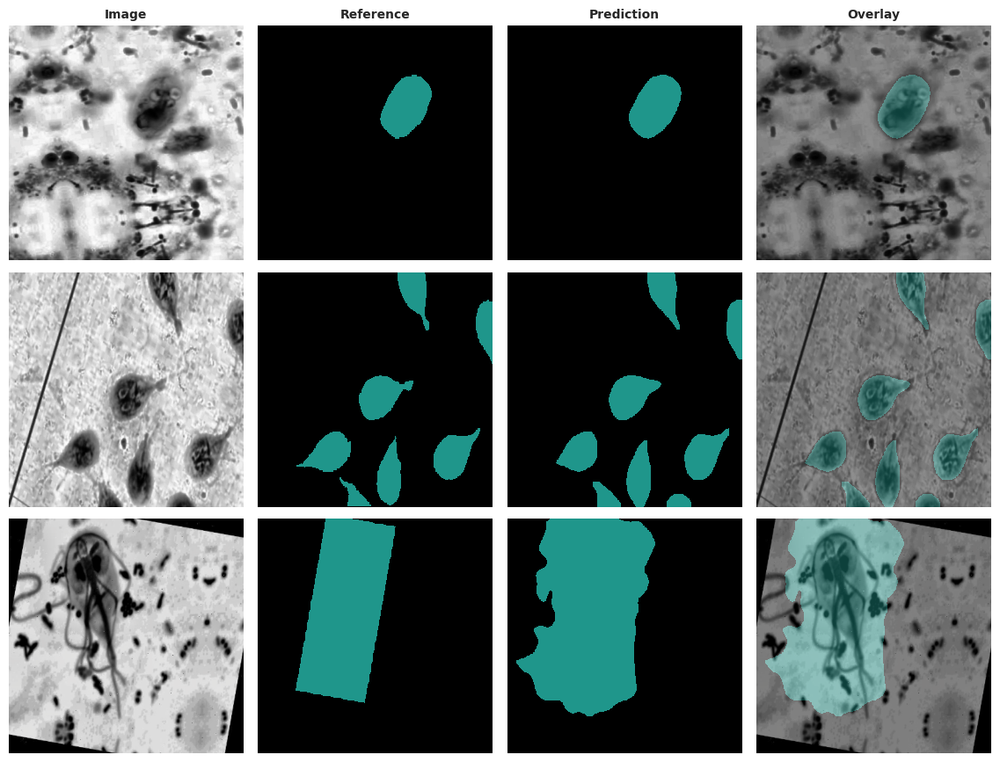

In [ ]:
scores = np.array([q["sample_dice"] for q in qualitative])
targets = [0.90, 0.50, 0.10]
case_indices = [int(np.argmin(np.abs(scores - np.quantile(scores, q)))) for q in targets]
case_names = ["Higher-overlap case", "Median case", "Difficult case"]

fig, axes = plt.subplots(3, 4, figsize=(11.5, 8.8))
for row, (idx, label) in enumerate(zip(case_indices, case_names)):
    q = qualitative[idx]
    image, gt, pred = denormalize(q["image"]), q["mask"].numpy(), q["pred"].numpy()
    axes[row, 0].imshow(image)
    axes[row, 1].imshow(gt, cmap=mask_cmap, norm=mask_norm, interpolation="nearest")
    axes[row, 2].imshow(pred, cmap=mask_cmap, norm=mask_norm, interpolation="nearest")
    axes[row, 3].imshow(image)
    axes[row, 3].imshow(pred, cmap=mask_cmap, norm=mask_norm, alpha=0.43, interpolation="nearest")
    axes[row, 0].set_ylabel(f"{label}\nDice = {q['sample_dice']:.3f}", fontsize=9, fontweight="bold")
    for ax in axes[row]: ax.axis("off")
for col, title in enumerate(["Image", "Reference", "Prediction", "Overlay"]):
    axes[0, col].set_title(title, fontsize=10)
fig.tight_layout()
save_figure(fig, "fig11_representative_difficulty_cases")
plt.show()


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig11_representative_difficulty_cases.png


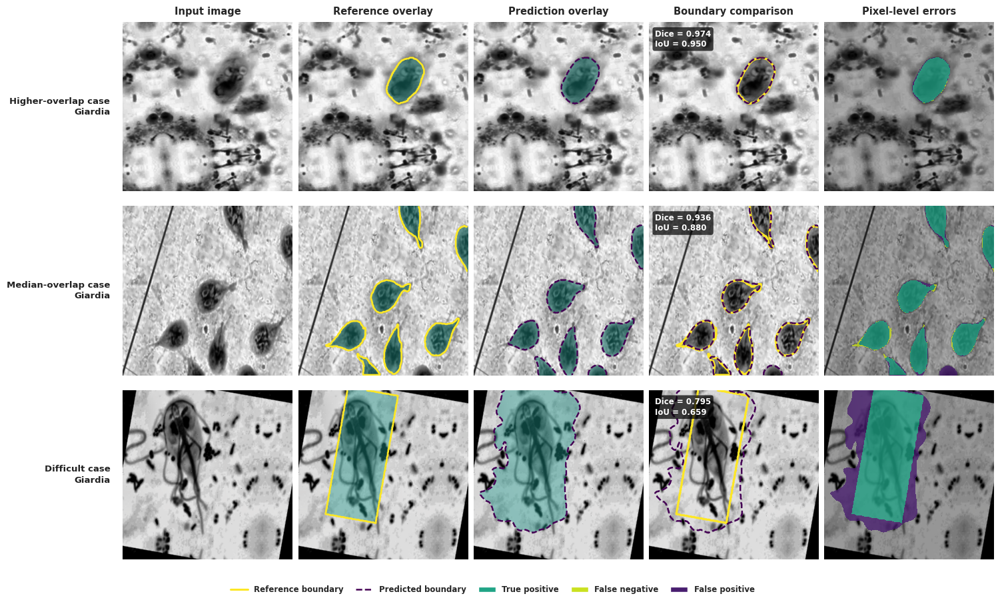

In [ ]:
scores = np.array([
    q["sample_dice"]
    for q in qualitative
])

target_quantiles = [0.90, 0.50, 0.10]

case_indices = [
    int(
        np.argmin(
            np.abs(
                scores - np.quantile(scores, quantile)
            )
        )
    )
    for quantile in target_quantiles
]

case_names = [
    "Higher-overlap case",
    "Median-overlap case",
    "Difficult case"
]

reference_color = "#FDE725"
prediction_color = "#440154"

# Error-map colors:
# transparent background, true positive, false negative, false positive
error_cmap = mpl.colors.ListedColormap([
    "#00000000",
    PALETTE[3],
    PALETTE[5],
    PALETTE[0]
])

error_norm = mpl.colors.BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    error_cmap.N
)

fig, axes = plt.subplots(
    3,
    5,
    figsize=(15.2, 9.2),
    gridspec_kw={
        "width_ratios": [1, 1, 1, 1, 1],
        "wspace": 0.035,
        "hspace": 0.075
    }
)

for row, (idx, case_name) in enumerate(
    zip(case_indices, case_names)
):

    q = qualitative[idx]

    image = denormalize(q["image"])
    ground_truth = q["mask"].numpy()
    prediction = q["pred"].numpy()

    gt_binary = ground_truth > 0
    pred_binary = prediction > 0

    intersection = np.logical_and(
        gt_binary,
        pred_binary
    ).sum()

    union = np.logical_or(
        gt_binary,
        pred_binary
    ).sum()

    sample_dice = (
        2.0 * intersection + 1e-6
    ) / (
        gt_binary.sum()
        + pred_binary.sum()
        + 1e-6
    )

    sample_iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    visible_reference = np.ma.masked_where(
        ground_truth == 0,
        ground_truth
    )

    visible_prediction = np.ma.masked_where(
        prediction == 0,
        prediction
    )

    # Pixel-level agreement map
    error_map = np.zeros_like(
        ground_truth,
        dtype=np.uint8
    )

    error_map[
        gt_binary & pred_binary
    ] = 1

    error_map[
        gt_binary & (~pred_binary)
    ] = 2

    error_map[
        (~gt_binary) & pred_binary
    ] = 3

    visible_error = np.ma.masked_where(
        error_map == 0,
        error_map
    )

    # Panel 1: Original image
    axes[row, 0].imshow(
        image,
        interpolation="bilinear"
    )

    # Panel 2: Reference-mask overlay
    axes[row, 1].imshow(
        image,
        interpolation="bilinear"
    )

    axes[row, 1].imshow(
        visible_reference,
        cmap=mask_cmap,
        norm=mask_norm,
        alpha=0.43,
        interpolation="nearest"
    )

    if gt_binary.any() and (~gt_binary).any():

        axes[row, 1].contour(
            gt_binary,
            levels=[0.5],
            colors=[reference_color],
            linewidths=1.9
        )

    # Panel 3: Predicted-mask overlay
    axes[row, 2].imshow(
        image,
        interpolation="bilinear"
    )

    axes[row, 2].imshow(
        visible_prediction,
        cmap=mask_cmap,
        norm=mask_norm,
        alpha=0.43,
        interpolation="nearest"
    )

    if pred_binary.any() and (~pred_binary).any():

        axes[row, 2].contour(
            pred_binary,
            levels=[0.5],
            colors=[prediction_color],
            linewidths=1.7,
            linestyles="--"
        )

    # Panel 4: Reference and predicted boundary comparison
    axes[row, 3].imshow(
        image,
        interpolation="bilinear"
    )

    if gt_binary.any() and (~gt_binary).any():

        axes[row, 3].contour(
            gt_binary,
            levels=[0.5],
            colors=[reference_color],
            linewidths=2.2
        )

    if pred_binary.any() and (~pred_binary).any():

        axes[row, 3].contour(
            pred_binary,
            levels=[0.5],
            colors=[prediction_color],
            linewidths=1.8,
            linestyles="--"
        )

    axes[row, 3].text(
        0.035,
        0.955,
        f"Dice = {sample_dice:.3f}\n"
        f"IoU = {sample_iou:.3f}",
        transform=axes[row, 3].transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        fontweight="bold",
        color="white",
        linespacing=1.25,
        bbox={
            "boxstyle": "round,pad=0.30",
            "facecolor": "black",
            "edgecolor": "none",
            "alpha": 0.72
        }
    )

    # Panel 5: Pixel-level agreement and error map
    axes[row, 4].imshow(
        np.clip(image * 0.68, 0, 1),
        interpolation="bilinear"
    )

    axes[row, 4].imshow(
        visible_error,
        cmap=error_cmap,
        norm=error_norm,
        alpha=0.78,
        interpolation="nearest"
    )

    # Visible case and pathogen labels
    if q["class_valid"]:

        pathogen_name = class_names[q["label"]]

    else:

        pathogen_name = "Unassigned class"

    axes[row, 0].text(
        -0.075,
        0.50,
        f"{case_name}\n{pathogen_name}",
        transform=axes[row, 0].transAxes,
        ha="right",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        color="#222222",
        linespacing=1.35,
        clip_on=False
    )

    for ax in axes[row]:
        ax.axis("off")

column_titles = [
    "Input image",
    "Reference overlay",
    "Prediction overlay",
    "Boundary comparison",
    "Pixel-level errors"
]

for col, title in enumerate(column_titles):

    axes[0, col].set_title(
        title,
        fontsize=10.5,
        fontweight="bold",
        pad=8
    )

legend_handles = [
    mpl.lines.Line2D(
        [0], [0],
        color=reference_color,
        linewidth=2.2,
        label="Reference boundary"
    ),
    mpl.lines.Line2D(
        [0], [0],
        color=prediction_color,
        linewidth=1.8,
        linestyle="--",
        label="Predicted boundary"
    ),
    mpl.patches.Patch(
        facecolor=PALETTE[3],
        label="True positive"
    ),
    mpl.patches.Patch(
        facecolor=PALETTE[5],
        label="False negative"
    ),
    mpl.patches.Patch(
        facecolor=PALETTE[0],
        label="False positive"
    )
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.008),
    ncol=5,
    fontsize=8.5,
    frameon=False,
    columnspacing=1.5,
    handlelength=2.2
)

fig.subplots_adjust(
    left=0.135,
    right=0.995,
    top=0.955,
    bottom=0.075
)

save_figure(
    fig,
    "fig11_representative_difficulty_cases"
)

plt.show()

## 15. Segmentation distribution and size-stratified analysis

Per-image overlap and boundary scores reveal variation that is hidden by aggregate pixel counts. Region size is defined by the percentage of reference foreground pixels: small below 2%, medium from 2% to 10%, and large above 10%. When the source annotations contain only boxes, these remain box-localization measures.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig12_localization_distribution_and_size.png


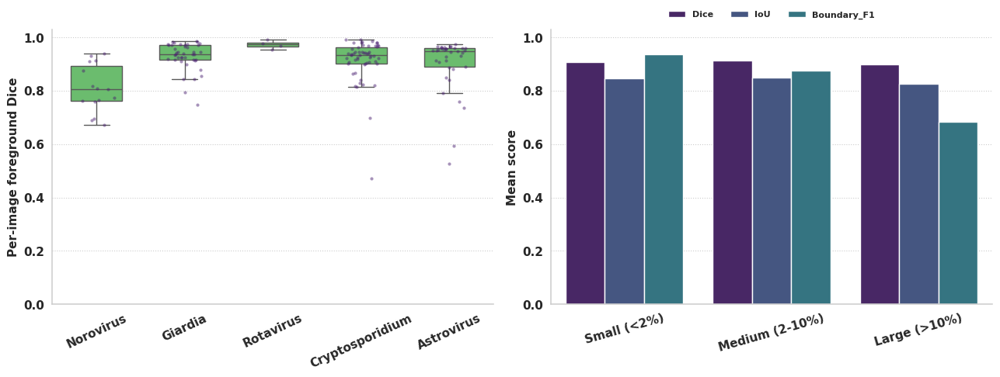

In [ ]:
def binary_iou(gt, pred, eps=1e-6):
    gt, pred = gt > 0, pred > 0
    return float((np.logical_and(gt, pred).sum() + eps) / (np.logical_or(gt, pred).sum() + eps))

def boundary_f1_score(gt, pred, tolerance=2, eps=1e-6):
    gt, pred = (gt > 0).astype(np.uint8), (pred > 0).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    gt_boundary = cv2.morphologyEx(gt, cv2.MORPH_GRADIENT, kernel) > 0
    pred_boundary = cv2.morphologyEx(pred, cv2.MORPH_GRADIENT, kernel) > 0
    if not gt_boundary.any() and not pred_boundary.any():
        return 1.0
    if not gt_boundary.any() or not pred_boundary.any():
        return 0.0
    tol_kernel = np.ones((2 * tolerance + 1, 2 * tolerance + 1), np.uint8)
    gt_dilated = cv2.dilate(gt_boundary.astype(np.uint8), tol_kernel) > 0
    pred_dilated = cv2.dilate(pred_boundary.astype(np.uint8), tol_kernel) > 0
    precision = np.logical_and(pred_boundary, gt_dilated).sum() / (pred_boundary.sum() + eps)
    recall = np.logical_and(gt_boundary, pred_dilated).sum() / (gt_boundary.sum() + eps)
    return float(2 * precision * recall / (precision + recall + eps))

localization_rows = []
for q in qualitative:
    gt, pred = q["mask"].numpy(), q["pred"].numpy()
    gt_pixels = gt > 0
    pred_pixels = pred > 0
    gt_area = 100.0 * gt_pixels.mean()
    pred_area = 100.0 * pred_pixels.mean()
    foreground_ids = gt[gt > 0]
    dominant_mask_id = int(np.bincount(foreground_ids, minlength=NUM_MASK_CLASSES).argmax()) if foreground_ids.size else 0
    localization_rows.append({
        "File": q["file_name"],
        "Class": mask_names[dominant_mask_id],
        "Dice": binary_dice(gt, pred),
        "IoU": binary_iou(gt, pred),
        "Boundary F1": boundary_f1_score(gt, pred, tolerance=2),
        "Reference area (%)": gt_area,
        "Predicted area (%)": pred_area,
        "Area error (pp)": pred_area - gt_area,
    })

localization_case_df = pd.DataFrame(localization_rows)
localization_case_df["Region size"] = pd.cut(
    localization_case_df["Reference area (%)"],
    bins=[-np.inf, 2.0, 10.0, np.inf], labels=["Small (<2%)", "Medium (2-10%)", "Large (>10%)"]
)
localization_case_df.to_csv(TABLE_DIR / "localization_per_image.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
sns.boxplot(data=localization_case_df, x="Class", y="Dice", color=PALETTE[4], width=0.58,
            showfliers=False, ax=axes[0])
sns.stripplot(data=localization_case_df, x="Class", y="Dice", color=PALETTE[0], size=3,
              alpha=0.48, jitter=0.20, ax=axes[0])
axes[0].set_ylim(0, 1.03)
axes[0].set_xlabel("")
axes[0].set_ylabel("Per-image foreground Dice")
axes[0].tick_params(axis="x", rotation=25)

size_summary = localization_case_df.groupby("Region size", observed=False).agg(
    Dice=("Dice", "mean"), IoU=("IoU", "mean"), Boundary_F1=("Boundary F1", "mean"),
    Images=("File", "size")
).reset_index()
size_long = size_summary.melt(id_vars=["Region size", "Images"], value_vars=["Dice", "IoU", "Boundary_F1"],
                              var_name="Metric", value_name="Score")
sns.barplot(data=size_long, x="Region size", y="Score", hue="Metric", palette=PALETTE[:3], ax=axes[1])
axes[1].set_ylim(0, 1.03)
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean score")
axes[1].tick_params(axis="x", rotation=16)
axes[1].legend(ncol=3, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.01))
for ax in axes: sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig12_localization_distribution_and_size")
plt.show()
size_summary.to_csv(TABLE_DIR / "localization_size_stratified.csv", index=False)


## 16. Region-area agreement and boundary localization

Area agreement identifies systematic over-localization or under-localization. The boundary panel compares reference and predicted contours on the same image without hiding either contour beneath a filled mask.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig13_area_agreement_and_boundaries.png


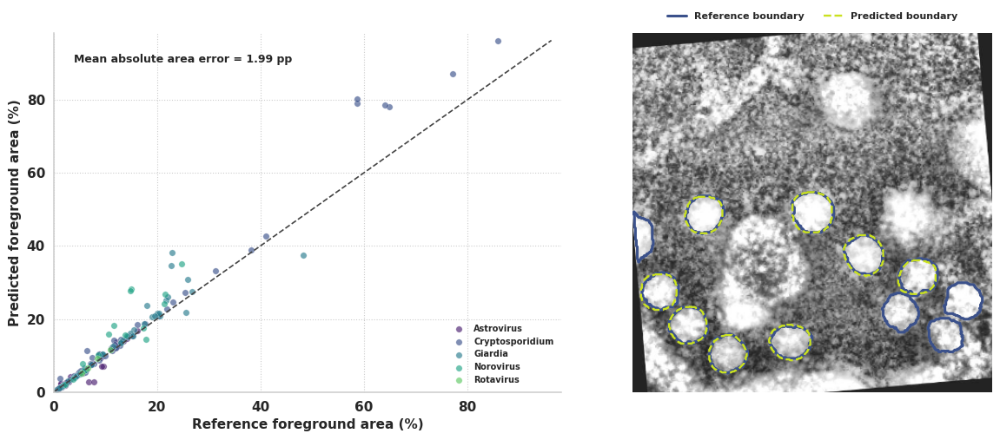

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
for c, name in enumerate(class_names):
    use = localization_case_df["Class"] == name
    axes[0].scatter(localization_case_df.loc[use, "Reference area (%)"],
                    localization_case_df.loc[use, "Predicted area (%)"],
                    s=28, alpha=0.65, color=PALETTE[c % len(PALETTE)], label=name,
                    edgecolors="white", linewidths=0.3)
limit = max(localization_case_df[["Reference area (%)", "Predicted area (%)"]].to_numpy().max(), 1)
axes[0].plot([0, limit], [0, limit], "--", color="#444444", lw=1.2)
mae_area = localization_case_df["Area error (pp)"].abs().mean()
axes[0].text(0.04, 0.92, f"Mean absolute area error = {mae_area:.2f} pp",
             transform=axes[0].transAxes, fontsize=9, fontweight="bold")
axes[0].set(xlabel="Reference foreground area (%)", ylabel="Predicted foreground area (%)",
            xlim=(0, limit * 1.02), ylim=(0, limit * 1.02))
axes[0].legend(fontsize=7)

boundary_idx = selected[0]
q = qualitative[boundary_idx]
image, gt, pred = denormalize(q["image"]), q["mask"].numpy(), q["pred"].numpy()
axes[1].imshow(image)
axes[1].contour(gt > 0, levels=[0.5], colors=PALETTE[1], linewidths=2.2)
axes[1].contour(pred > 0, levels=[0.5], colors=PALETTE[5], linewidths=1.7, linestyles="--")
axes[1].plot([], [], color=PALETTE[1], lw=2.2, label="Reference boundary")
axes[1].plot([], [], color=PALETTE[5], lw=1.7, ls="--", label="Predicted boundary")
axes[1].legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
axes[1].axis("off")
for ax in axes: sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig13_area_agreement_and_boundaries")
plt.show()


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig13_area_agreement_boundaries_and_gradcam.png


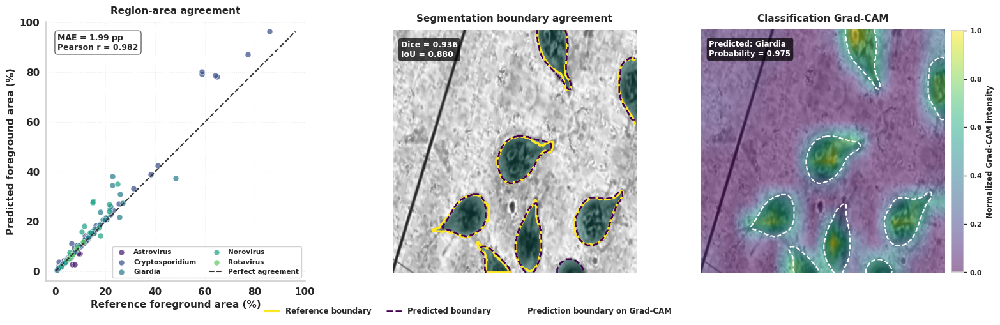

In [ ]:
def classification_gradcam(
    image_tensor,
    target_class=None
):
    """
    Generate Grad-CAM from the deepest encoder feature map.

    Parameters
    ----------
    image_tensor : torch.Tensor
        Normalized image tensor with shape [C, H, W].
    target_class : int or None
        Class used for backpropagation. If None, the predicted
        class is used.
    """

    model.eval()

    captured = {}

    def encoder_hook(module, inputs, output):

        feature_map = (
            output[-1]
            if isinstance(output, (list, tuple))
            else output
        )

        captured["activation"] = feature_map

        feature_map.register_hook(
            lambda gradient:
            captured.__setitem__("gradient", gradient)
        )

    hook_handle = model.encoder.register_forward_hook(
        encoder_hook
    )

    try:

        input_tensor = (
            image_tensor
            .unsqueeze(0)
            .to(device)
        )

        model.zero_grad(set_to_none=True)

        outputs = model(input_tensor)
        logits = outputs["cls_logits"]
        probabilities = torch.softmax(logits, dim=1)

        predicted_class = int(
            probabilities.argmax(dim=1).item()
        )

        if target_class is None:
            target_class = predicted_class

        class_score = logits[0, target_class]
        class_score.backward()

        activation = captured["activation"]
        gradient = captured["gradient"]

        # Global-average pooling of gradients
        weights = gradient.mean(
            dim=(2, 3),
            keepdim=True
        )

        gradcam = (
            weights * activation
        ).sum(dim=1, keepdim=True)

        gradcam = F.relu(gradcam)

        gradcam = F.interpolate(
            gradcam,
            size=image_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        gradcam = gradcam[0, 0]

        gradcam -= gradcam.min()
        gradcam /= gradcam.max().clamp_min(1e-8)

        predicted_probability = float(
            probabilities[0, predicted_class].detach().cpu()
        )

        return (
            gradcam.detach().cpu().numpy(),
            predicted_class,
            predicted_probability
        )

    finally:

        hook_handle.remove()
        model.zero_grad(set_to_none=True)


# ---------------------------------------------------------
# Select a representative sample near the median Dice score
# ---------------------------------------------------------

valid_indices = [
    i for i, q in enumerate(qualitative)
    if q["class_valid"]
]

if not valid_indices:
    raise RuntimeError(
        "No valid classified test samples are available."
    )

valid_dice = np.array([
    qualitative[i]["sample_dice"]
    for i in valid_indices
])

median_dice = np.median(valid_dice)

boundary_idx = valid_indices[
    int(
        np.argmin(
            np.abs(valid_dice - median_dice)
        )
    )
]

q = qualitative[boundary_idx]

image = denormalize(q["image"])
ground_truth = q["mask"].numpy()
prediction = q["pred"].numpy()

gt_binary = ground_truth > 0
pred_binary = prediction > 0

intersection = np.logical_and(
    gt_binary,
    pred_binary
).sum()

union = np.logical_or(
    gt_binary,
    pred_binary
).sum()

sample_dice = (
    2.0 * intersection + 1e-6
) / (
    gt_binary.sum()
    + pred_binary.sum()
    + 1e-6
)

sample_iou = (
    intersection + 1e-6
) / (
    union + 1e-6
)

gradcam_map, predicted_class, predicted_probability = (
    classification_gradcam(q["image"])
)

reference_color = "#FDE725"
prediction_color = "#440154"


# ---------------------------------------------------------
# Improved three-panel figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16.0, 5.2),
    gridspec_kw={
        "width_ratios": [1.25, 1.0, 1.08],
        "wspace": 0.24
    }
)


# =========================================================
# Panel 1: Region-area agreement
# =========================================================

for class_id, class_name in enumerate(class_names):

    use = (
        localization_case_df["Class"]
        == class_name
    )

    axes[0].scatter(
        localization_case_df.loc[
            use,
            "Reference area (%)"
        ],
        localization_case_df.loc[
            use,
            "Predicted area (%)"
        ],
        s=42,
        alpha=0.72,
        color=PALETTE[
            class_id % len(PALETTE)
        ],
        label=class_name,
        edgecolors="white",
        linewidths=0.55
    )

area_values = localization_case_df[
    [
        "Reference area (%)",
        "Predicted area (%)"
    ]
].to_numpy()

limit = max(
    np.nanmax(area_values),
    1.0
)

margin = limit * 0.04

axes[0].plot(
    [0, limit],
    [0, limit],
    linestyle="--",
    color="#333333",
    linewidth=1.5,
    label="Perfect agreement"
)

mae_area = (
    localization_case_df[
        "Area error (pp)"
    ]
    .abs()
    .mean()
)

reference_areas = localization_case_df[
    "Reference area (%)"
].to_numpy()

predicted_areas = localization_case_df[
    "Predicted area (%)"
].to_numpy()

if (
    np.std(reference_areas) > 0
    and np.std(predicted_areas) > 0
):

    area_correlation = np.corrcoef(
        reference_areas,
        predicted_areas
    )[0, 1]

else:

    area_correlation = np.nan

correlation_text = (
    f"{area_correlation:.3f}"
    if np.isfinite(area_correlation)
    else "NA"
)

axes[0].text(
    0.045,
    0.955,
    f"MAE = {mae_area:.2f} pp\n"
    f"Pearson r = {correlation_text}",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=9,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#555555",
        "alpha": 0.90
    }
)

axes[0].set_xlim(
    -margin,
    limit + margin
)

axes[0].set_ylim(
    -margin,
    limit + margin
)

axes[0].set_aspect(
    "equal",
    adjustable="box"
)

axes[0].set_xlabel(
    "Reference foreground area (%)",
    fontweight="bold"
)

axes[0].set_ylabel(
    "Predicted foreground area (%)",
    fontweight="bold"
)

axes[0].grid(
    linestyle=":",
    linewidth=0.8,
    alpha=0.35
)

axes[0].legend(
    fontsize=7.5,
    ncol=2,
    loc="lower right",
    frameon=True,
    framealpha=0.90
)

axes[0].set_title(
    "Region-area agreement",
    fontsize=11,
    fontweight="bold",
    pad=9
)


# =========================================================
# Panel 2: Segmentation boundary agreement
# =========================================================

axes[1].imshow(
    image,
    interpolation="bilinear"
)

visible_prediction = np.ma.masked_where(
    prediction == 0,
    prediction
)

axes[1].imshow(
    visible_prediction,
    cmap=mask_cmap,
    norm=mask_norm,
    alpha=0.30,
    interpolation="nearest"
)

if gt_binary.any() and (~gt_binary).any():

    axes[1].contour(
        gt_binary,
        levels=[0.5],
        colors=[reference_color],
        linewidths=2.3
    )

if pred_binary.any() and (~pred_binary).any():

    axes[1].contour(
        pred_binary,
        levels=[0.5],
        colors=[prediction_color],
        linewidths=1.9,
        linestyles="--"
    )

axes[1].text(
    0.035,
    0.955,
    f"Dice = {sample_dice:.3f}\n"
    f"IoU = {sample_iou:.3f}",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=9,
    fontweight="bold",
    color="white",
    bbox={
        "boxstyle": "round,pad=0.32",
        "facecolor": "black",
        "edgecolor": "none",
        "alpha": 0.72
    }
)

axes[1].set_title(
    "Segmentation boundary agreement",
    fontsize=11,
    fontweight="bold",
    pad=9
)

axes[1].axis("off")


# =========================================================
# Panel 3: Classification Grad-CAM
# =========================================================

axes[2].imshow(
    image,
    interpolation="bilinear"
)

gradcam_artist = axes[2].imshow(
    gradcam_map,
    cmap="viridis",
    vmin=0,
    vmax=1,
    alpha=0.52,
    interpolation="bilinear"
)

if pred_binary.any() and (~pred_binary).any():

    axes[2].contour(
        pred_binary,
        levels=[0.5],
        colors=["white"],
        linewidths=1.5,
        linestyles="--"
    )

axes[2].text(
    0.035,
    0.955,
    f"Predicted: {class_names[predicted_class]}\n"
    f"Probability = {predicted_probability:.3f}",
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=8.5,
    fontweight="bold",
    color="white",
    bbox={
        "boxstyle": "round,pad=0.32",
        "facecolor": "black",
        "edgecolor": "none",
        "alpha": 0.72
    }
)

axes[2].set_title(
    "Classification Grad-CAM",
    fontsize=11,
    fontweight="bold",
    pad=9
)

axes[2].axis("off")

colorbar = fig.colorbar(
    gradcam_artist,
    ax=axes[2],
    fraction=0.046,
    pad=0.025
)

colorbar.set_label(
    "Normalized Grad-CAM intensity",
    fontsize=8.5,
    fontweight="bold"
)

colorbar.ax.tick_params(
    labelsize=8
)


# =========================================================
# Shared boundary legend
# =========================================================

boundary_handles = [
    mpl.lines.Line2D(
        [0], [0],
        color=reference_color,
        linewidth=2.3,
        label="Reference boundary"
    ),
    mpl.lines.Line2D(
        [0], [0],
        color=prediction_color,
        linewidth=1.9,
        linestyle="--",
        label="Predicted boundary"
    ),
    mpl.lines.Line2D(
        [0], [0],
        color="white",
        markeredgecolor="#333333",
        linewidth=1.5,
        linestyle="--",
        label="Prediction boundary on Grad-CAM"
    )
]

fig.legend(
    handles=boundary_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    ncol=3,
    fontsize=8.5,
    frameon=False
)

sns.despine(ax=axes[0])

fig.subplots_adjust(
    left=0.065,
    right=0.985,
    top=0.91,
    bottom=0.13
)

save_figure(
    fig,
    "fig13_area_agreement_boundaries_and_gradcam"
)

plt.show()

## 17. Classification confidence, margin, and entropy

Correct and incorrect predictions are compared using maximum probability, the gap between the two highest probabilities, and predictive entropy. These distributions help distinguish confident errors from ambiguous cases.


/tmp/ipykernel_489/759209717.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=classification_diag_df, x="Outcome", y=metric,
/tmp/ipykernel_489/759209717.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=classification_diag_df, x="Outcome", y=metric,
/tmp/ipykernel_489/759209717.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=classification_diag_df, x="Outcome", y=metric,


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig14_classification_confidence_diagnostics.png


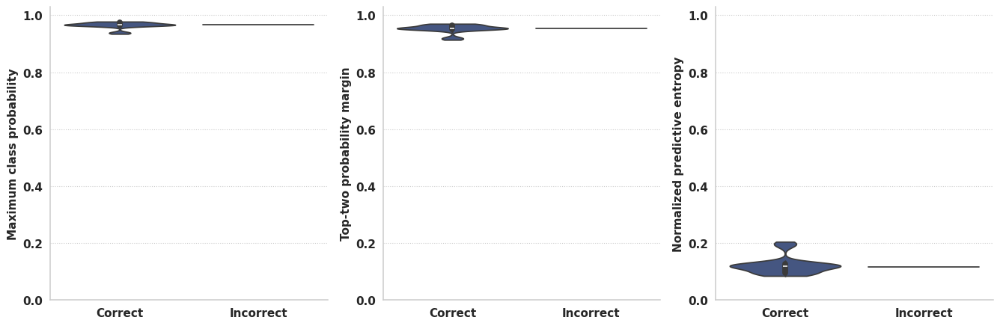

In [ ]:
sorted_prob = np.sort(y_prob, axis=1)
confidence = sorted_prob[:, -1]
margin = sorted_prob[:, -1] - sorted_prob[:, -2]
entropy = -(y_prob * np.log(y_prob.clip(1e-12, 1))).sum(axis=1) / np.log(NUM_CLASSES)
classification_diag_df = pd.DataFrame({
    "File": evaluated_names,
    "True class": [class_names[i] for i in y_true],
    "Predicted class": [class_names[i] for i in y_pred],
    "Outcome": np.where(y_true == y_pred, "Correct", "Incorrect"),
    "Confidence": confidence,
    "Top-two margin": margin,
    "Normalized entropy": entropy,
})
classification_diag_df.to_csv(TABLE_DIR / "classification_confidence_diagnostics.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
for ax, metric, ylabel in zip(
    axes,
    ["Confidence", "Top-two margin", "Normalized entropy"],
    ["Maximum class probability", "Top-two probability margin", "Normalized predictive entropy"]
):
    sns.violinplot(data=classification_diag_df, x="Outcome", y=metric,
                   palette={"Correct": PALETTE[1], "Incorrect": PALETTE[5]}, inner="box", cut=0, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.03)
    sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig14_classification_confidence_diagnostics")
plt.show()


## 18. Mean probability matrix

Each cell gives the mean probability assigned to a predicted class for samples belonging to a given true class. Unlike a hard confusion matrix, this view retains uncertainty and shows secondary class competition.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig15_mean_class_probability_matrix.png


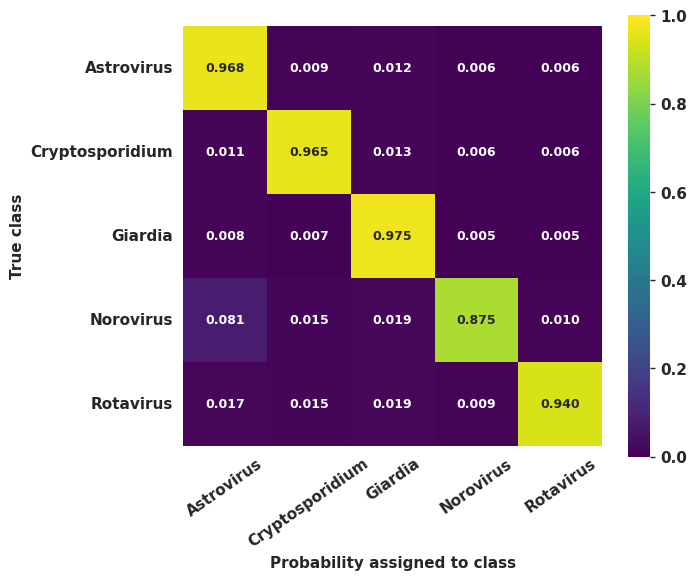

In [ ]:
mean_probability = np.vstack([
    y_prob[y_true == c].mean(axis=0) if np.any(y_true == c) else np.full(NUM_CLASSES, np.nan)
    for c in range(NUM_CLASSES)
])
fig, ax = plt.subplots(figsize=(7.3, 6.0))
sns.heatmap(mean_probability, annot=True, fmt=".3f", cmap="viridis", vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names, square=True, ax=ax,
            annot_kws={"fontsize": 9, "fontweight": "bold"})
ax.set_xlabel("Probability assigned to class")
ax.set_ylabel("True class")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
save_figure(fig, "fig15_mean_class_probability_matrix")
plt.show()
pd.DataFrame(mean_probability, index=class_names, columns=class_names).to_csv(TABLE_DIR / "mean_class_probability_matrix.csv")


## 19. Model-agnostic classification occlusion maps

Occlusion sensitivity measures the reduction in the predicted-class probability when a local image block is hidden. It provides a classification-specific visual check that is separate from the localization output. The map should be interpreted as sensitivity to occlusion, not as a causal explanation.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig16_compact_occlusion_sensitivity.png


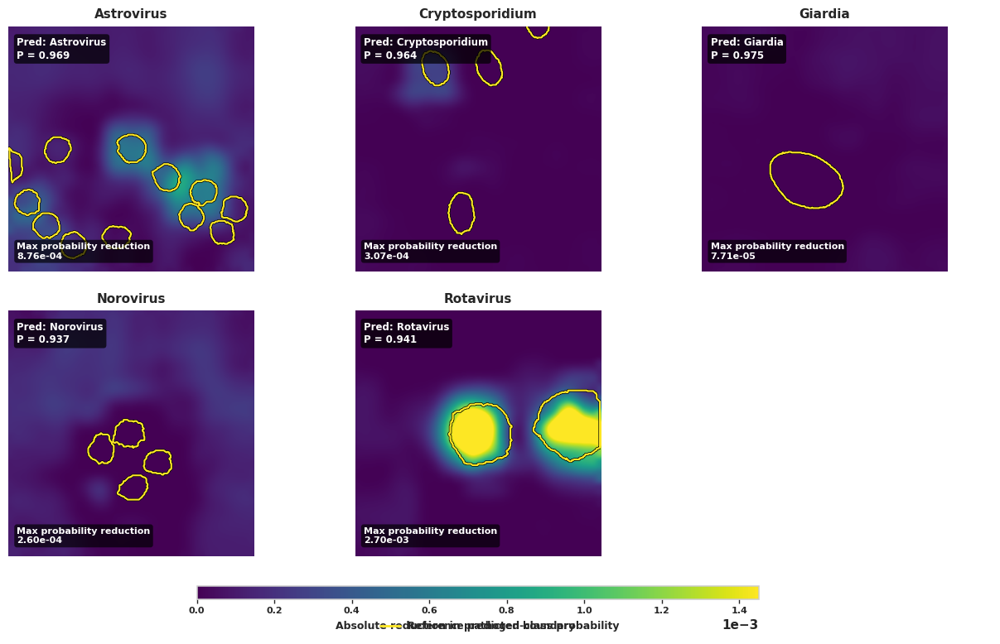

In [ ]:
@torch.inference_mode()
def occlusion_sensitivity(
    image_tensor,
    patch_fraction=0.16,
    stride_fraction=0.05,
    batch_size=32
):
    """
    Dense overlapping occlusion sensitivity.

    Returns the absolute reduction in predicted-class probability.
    Maps are not normalized independently.
    """

    model.eval()

    input_tensor = (
        image_tensor
        .unsqueeze(0)
        .to(device)
    )

    base_probabilities = torch.softmax(
        model(input_tensor)["cls_logits"],
        dim=1
    )[0]

    target_class = int(
        base_probabilities.argmax().item()
    )

    baseline_probability = float(
        base_probabilities[target_class].item()
    )

    _, height, width = image_tensor.shape

    patch_height = min(
        height,
        max(8, int(round(height * patch_fraction)))
    )

    patch_width = min(
        width,
        max(8, int(round(width * patch_fraction)))
    )

    stride = max(
        4,
        int(round(min(height, width) * stride_fraction))
    )

    def obtain_positions(length, patch_size):

        final_position = max(
            length - patch_size,
            0
        )

        positions = list(
            range(
                0,
                final_position + 1,
                stride
            )
        )

        if not positions or positions[-1] != final_position:
            positions.append(final_position)

        return positions

    y_positions = obtain_positions(
        height,
        patch_height
    )

    x_positions = obtain_positions(
        width,
        patch_width
    )

    locations = [
        (
            y,
            min(y + patch_height, height),
            x,
            min(x + patch_width, width)
        )
        for y in y_positions
        for x in x_positions
    ]

    sensitivity_sum = np.zeros(
        (height, width),
        dtype=np.float32
    )

    weight_sum = np.zeros(
        (height, width),
        dtype=np.float32
    )

    vertical_weight = np.hanning(
        patch_height
    )

    horizontal_weight = np.hanning(
        patch_width
    )

    spatial_weight = np.outer(
        vertical_weight,
        horizontal_weight
    ).astype(np.float32)

    spatial_weight = np.maximum(
        spatial_weight,
        0.05
    )

    for start in range(
        0,
        len(locations),
        batch_size
    ):

        current_locations = locations[
            start:start + batch_size
        ]

        variants = []

        for y1, y2, x1, x2 in current_locations:

            occluded = image_tensor.clone()

            # Zero corresponds to the normalization mean.
            occluded[:, y1:y2, x1:x2] = 0.0

            variants.append(occluded)

        batch = torch.stack(
            variants
        ).to(device)

        current_probabilities = torch.softmax(
            model(batch)["cls_logits"],
            dim=1
        )[:, target_class]

        current_probabilities = (
            current_probabilities
            .cpu()
            .numpy()
        )

        for location, probability in zip(
            current_locations,
            current_probabilities
        ):

            y1, y2, x1, x2 = location

            probability_reduction = max(
                0.0,
                baseline_probability
                - float(probability)
            )

            local_weight = spatial_weight[
                :y2 - y1,
                :x2 - x1
            ]

            sensitivity_sum[
                y1:y2,
                x1:x2
            ] += probability_reduction * local_weight

            weight_sum[
                y1:y2,
                x1:x2
            ] += local_weight

    sensitivity = sensitivity_sum / np.maximum(
        weight_sum,
        1e-8
    )

    sensitivity = cv2.GaussianBlur(
        sensitivity,
        ksize=(0, 0),
        sigmaX=max(height, width) * 0.01,
        sigmaY=max(height, width) * 0.01
    )

    maximum_reduction = float(
        sensitivity.max()
    )

    return (
        sensitivity,
        target_class,
        baseline_probability,
        maximum_reduction
    )


# ---------------------------------------------------------
# Generate one explanation for each represented class
# ---------------------------------------------------------

occlusion_examples = selected[
    :min(NUM_CLASSES, len(selected))
]

if not occlusion_examples:
    raise RuntimeError(
        "No samples are available for occlusion analysis."
    )

occlusion_results = []

for idx in occlusion_examples:

    q = qualitative[idx]

    (
        sensitivity,
        predicted_class,
        predicted_probability,
        maximum_reduction
    ) = occlusion_sensitivity(
        q["image"],
        patch_fraction=0.16,
        stride_fraction=0.05,
        batch_size=32
    )

    occlusion_results.append({
        "index": idx,
        "sensitivity": sensitivity,
        "predicted_class": predicted_class,
        "predicted_probability": predicted_probability,
        "maximum_reduction": maximum_reduction
    })


# ---------------------------------------------------------
# Use one shared absolute sensitivity scale
# ---------------------------------------------------------

positive_values = np.concatenate([
    result["sensitivity"][
        result["sensitivity"] > 0
    ]
    for result in occlusion_results
    if np.any(result["sensitivity"] > 0)
])

if positive_values.size:

    shared_vmax = float(
        np.percentile(
            positive_values,
            99
        )
    )

else:

    shared_vmax = 1e-6

shared_vmax = max(
    shared_vmax,
    1e-8
)


# ---------------------------------------------------------
# Compact overlay-only gallery
# ---------------------------------------------------------

number_of_examples = len(
    occlusion_results
)

number_of_columns = 3

number_of_rows = math.ceil(
    number_of_examples / number_of_columns
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(
        12.8,
        4.0 * number_of_rows
    )
)

axes = np.asarray(
    axes
).reshape(
    number_of_rows,
    number_of_columns
)

reference_color = "#FDE725"

used_axes = []
heatmap_artist = None

for panel_index, result in enumerate(
    occlusion_results
):

    row = panel_index // number_of_columns
    col = panel_index % number_of_columns

    ax = axes[row, col]
    used_axes.append(ax)

    q = qualitative[
        result["index"]
    ]

    image = denormalize(
        q["image"]
    )

    ground_truth = q["mask"].numpy()
    gt_binary = ground_truth > 0

    sensitivity = result["sensitivity"]

    relative_sensitivity = np.clip(
        sensitivity / shared_vmax,
        0,
        1
    )

    # Weak responses remain transparent.
    # Only responses exceeding 8% of the shared scale are visible.
    overlay_alpha = np.where(
        relative_sensitivity >= 0.08,
        0.15 + 0.65 * (
            relative_sensitivity ** 0.75
        ),
        0.0
    )

    ax.imshow(
        image,
        interpolation="bilinear"
    )

    heatmap_artist = ax.imshow(
        sensitivity,
        cmap="viridis",
        vmin=0,
        vmax=shared_vmax,
        alpha=overlay_alpha,
        interpolation="bilinear"
    )

    # Reference boundary provides spatial context.
    if gt_binary.any() and (~gt_binary).any():

        # Dark outer stroke
        ax.contour(
            gt_binary,
            levels=[0.5],
            colors=["black"],
            linewidths=2.5
        )

        # Viridis-yellow inner stroke
        ax.contour(
            gt_binary,
            levels=[0.5],
            colors=[reference_color],
            linewidths=1.5
        )

    true_class_name = (
        class_names[q["label"]]
        if q["class_valid"]
        else "Unassigned"
    )

    predicted_class_name = class_names[
        result["predicted_class"]
    ]

    ax.set_title(
        true_class_name,
        fontsize=11,
        fontweight="bold",
        pad=7
    )

    ax.text(
        0.035,
        0.955,
        f"Pred: {predicted_class_name}\n"
        f"P = {result['predicted_probability']:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        fontweight="bold",
        color="white",
        linespacing=1.25,
        bbox={
            "boxstyle": "round,pad=0.30",
            "facecolor": "black",
            "edgecolor": "none",
            "alpha": 0.72
        }
    )

    ax.text(
        0.035,
        0.045,
        "Max probability reduction\n"
        f"{result['maximum_reduction']:.2e}",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="white",
        linespacing=1.20,
        bbox={
            "boxstyle": "round,pad=0.28",
            "facecolor": "black",
            "edgecolor": "none",
            "alpha": 0.68
        }
    )

    ax.axis("off")


# Hide unused panels
for panel_index in range(
    number_of_examples,
    number_of_rows * number_of_columns
):

    row = panel_index // number_of_columns
    col = panel_index % number_of_columns

    axes[row, col].axis("off")


# ---------------------------------------------------------
# Shared absolute color scale
# ---------------------------------------------------------

colorbar_axis = fig.add_axes([
    0.235,
    0.075,
    0.53,
    0.020
])

colorbar = fig.colorbar(
    heatmap_artist,
    cax=colorbar_axis,
    orientation="horizontal"
)

colorbar.set_label(
    "Absolute reduction in predicted-class probability",
    fontsize=9,
    fontweight="bold",
    labelpad=5
)

colorbar.ax.tick_params(
    labelsize=8
)

colorbar.formatter.set_powerlimits(
    (-2, 2)
)

colorbar.update_ticks()


boundary_handle = mpl.lines.Line2D(
    [0],
    [0],
    color=reference_color,
    markeredgecolor="black",
    linewidth=2.0,
    label="Reference pathogen boundary"
)

fig.legend(
    handles=[boundary_handle],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.012),
    fontsize=8.5,
    frameon=False
)

fig.subplots_adjust(
    left=0.015,
    right=0.985,
    top=0.94,
    bottom=0.14,
    wspace=0.035,
    hspace=0.16
)

save_figure(
    fig,
    "fig16_compact_occlusion_sensitivity"
)

plt.show()

Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig16_sparse_occlusion_overlays.png


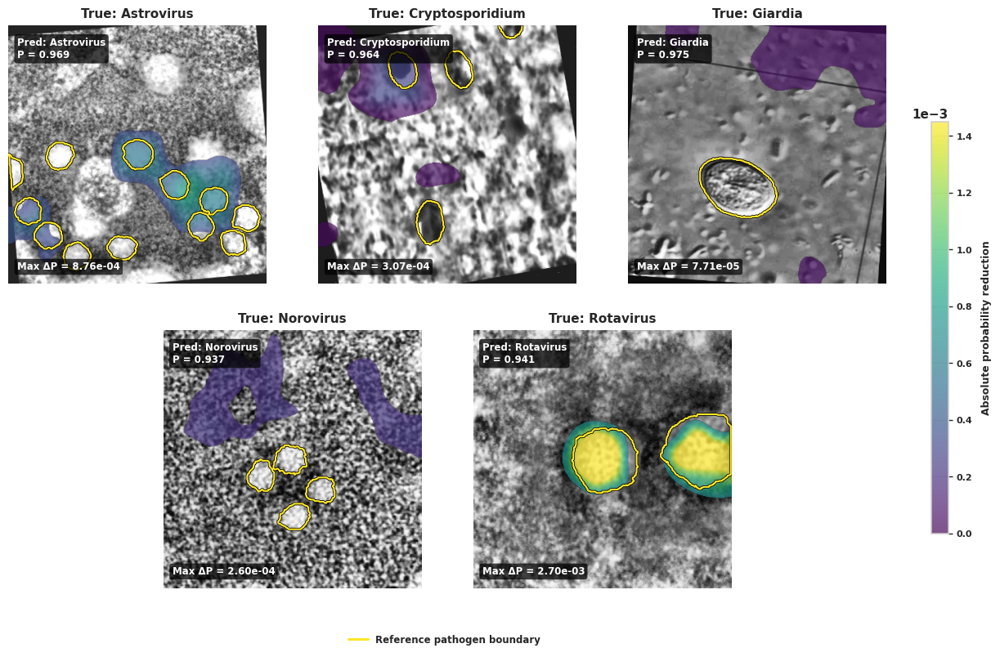

In [ ]:
# =========================================================
# Journal-style sparse occlusion visualization
# Requires:
# occlusion_results and shared_vmax from the previous code
# =========================================================

number_of_examples = len(occlusion_results)

if number_of_examples == 0:
    raise RuntimeError(
        "No occlusion results are available."
    )

# Symmetric arrangement for five pathogen classes:
# three panels in the first row and two centered panels below.
fig = plt.figure(
    figsize=(12.8, 8.4)
)

grid = fig.add_gridspec(
    2,
    6,
    left=0.025,
    right=0.90,
    top=0.94,
    bottom=0.12,
    wspace=0.10,
    hspace=0.18
)

if number_of_examples == 5:

    axes = [
        fig.add_subplot(grid[0, 0:2]),
        fig.add_subplot(grid[0, 2:4]),
        fig.add_subplot(grid[0, 4:6]),
        fig.add_subplot(grid[1, 1:3]),
        fig.add_subplot(grid[1, 3:5])
    ]

else:

    # General fallback for a different number of classes
    rows = math.ceil(number_of_examples / 3)

    fallback_grid = fig.add_gridspec(
        rows,
        3,
        left=0.025,
        right=0.90,
        top=0.94,
        bottom=0.12,
        wspace=0.08,
        hspace=0.18
    )

    axes = [
        fig.add_subplot(
            fallback_grid[i // 3, i % 3]
        )
        for i in range(number_of_examples)
    ]

reference_color = "#FDE725"
heatmap_artist = None

for panel_index, result in enumerate(
    occlusion_results
):

    ax = axes[panel_index]

    q = qualitative[
        result["index"]
    ]

    image = denormalize(
        q["image"]
    )

    sensitivity = result["sensitivity"]

    ground_truth = q["mask"].numpy()
    gt_binary = ground_truth > 0

    positive_values = sensitivity[
        sensitivity > 0
    ]

    # Display only the strongest 15% of responses in each image.
    # The actual colors still use the shared absolute scale.
    if positive_values.size:

        display_threshold = np.quantile(
            positive_values,
            0.85
        )

    else:

        display_threshold = np.inf

    visible_sensitivity = np.ma.masked_where(
        sensitivity < display_threshold,
        sensitivity
    )

    # Original image remains fully visible.
    ax.imshow(
        image,
        interpolation="bilinear"
    )

    # Only the strongest response regions are overlaid.
    heatmap_artist = ax.imshow(
        visible_sensitivity,
        cmap="viridis",
        vmin=0,
        vmax=shared_vmax,
        alpha=0.68,
        interpolation="bilinear"
    )

    # Double-stroke reference boundary for visibility
    if gt_binary.any() and (~gt_binary).any():

        ax.contour(
            gt_binary,
            levels=[0.5],
            colors=["black"],
            linewidths=2.6
        )

        ax.contour(
            gt_binary,
            levels=[0.5],
            colors=[reference_color],
            linewidths=1.5
        )

    true_class_name = (
        class_names[q["label"]]
        if q["class_valid"]
        else "Unassigned"
    )

    predicted_class_name = class_names[
        result["predicted_class"]
    ]

    ax.set_title(
        f"True: {true_class_name}",
        fontsize=11,
        fontweight="bold",
        pad=7
    )

    ax.text(
        0.035,
        0.955,
        f"Pred: {predicted_class_name}\n"
        f"P = {result['predicted_probability']:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        fontweight="bold",
        color="white",
        linespacing=1.25,
        bbox={
            "boxstyle": "round,pad=0.30",
            "facecolor": "black",
            "edgecolor": "none",
            "alpha": 0.74
        }
    )

    ax.text(
        0.035,
        0.045,
        f"Max ΔP = "
        f"{result['maximum_reduction']:.2e}",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
        color="white",
        bbox={
            "boxstyle": "round,pad=0.28",
            "facecolor": "black",
            "edgecolor": "none",
            "alpha": 0.72
        }
    )

    ax.axis("off")


# ---------------------------------------------------------
# Vertical shared color bar
# ---------------------------------------------------------

colorbar_axis = fig.add_axes([
    0.925,
    0.20,
    0.016,
    0.60
])

colorbar = fig.colorbar(
    heatmap_artist,
    cax=colorbar_axis,
    orientation="vertical"
)

colorbar.set_label(
    "Absolute probability reduction",
    fontsize=9,
    fontweight="bold",
    labelpad=8
)

colorbar.ax.tick_params(
    labelsize=8
)

colorbar.formatter.set_powerlimits(
    (-2, 2)
)

colorbar.update_ticks()


# ---------------------------------------------------------
# Compact boundary legend
# ---------------------------------------------------------

boundary_handle = mpl.lines.Line2D(
    [0],
    [0],
    color=reference_color,
    linewidth=2.2,
    markeredgecolor="black",
    label="Reference pathogen boundary"
)

fig.legend(
    handles=[boundary_handle],
    loc="lower center",
    bbox_to_anchor=(0.46, 0.025),
    fontsize=8.5,
    frameon=False
)

save_figure(
    fig,
    "fig16_sparse_occlusion_overlays"
)

plt.show()

## 20. Classification error audit

The most confident incorrect predictions are listed first. This table supports case-level review and should be examined before making claims about difficult pathogen pairs.


In [ ]:
error_rows = []
for name, truth, pred, prob in zip(evaluated_names, y_true, y_pred, y_prob):
    if truth != pred:
        error_rows.append({
            "File": name, "True class": class_names[truth], "Predicted class": class_names[pred],
            "Predicted confidence": prob[pred], "True-class probability": prob[truth],
            "Confidence margin": prob[pred] - prob[truth]
        })
error_columns = ["File", "True class", "Predicted class", "Predicted confidence", "True-class probability", "Confidence margin"]
error_df = pd.DataFrame(error_rows, columns=error_columns).sort_values("Predicted confidence", ascending=False)
if error_df.empty:
    print("No classification errors occurred on the evaluated test images.")
else:
    display(error_df.head(20).style.format({
        "Predicted confidence": "{:.3f}", "True-class probability": "{:.3f}", "Confidence margin": "{:.3f}"
    }))
error_df.to_csv(TABLE_DIR / "classification_error_audit.csv", index=False)


,File,True class,Predicted class,Predicted confidence,True-class probability,Confidence margin
0,Noravirus_32_png.rf.c33657910ed5518d5236c0ad505a8e7f.jpg,Norovirus,Astrovirus,0.967,0.007,0.961


### 20.1 Most confident classification errors

When errors are present, this panel displays up to eight cases ranked by predicted confidence. The true and predicted labels are printed together so visual review can focus on confidently confused samples.


Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig16a_confident_classification_errors.png


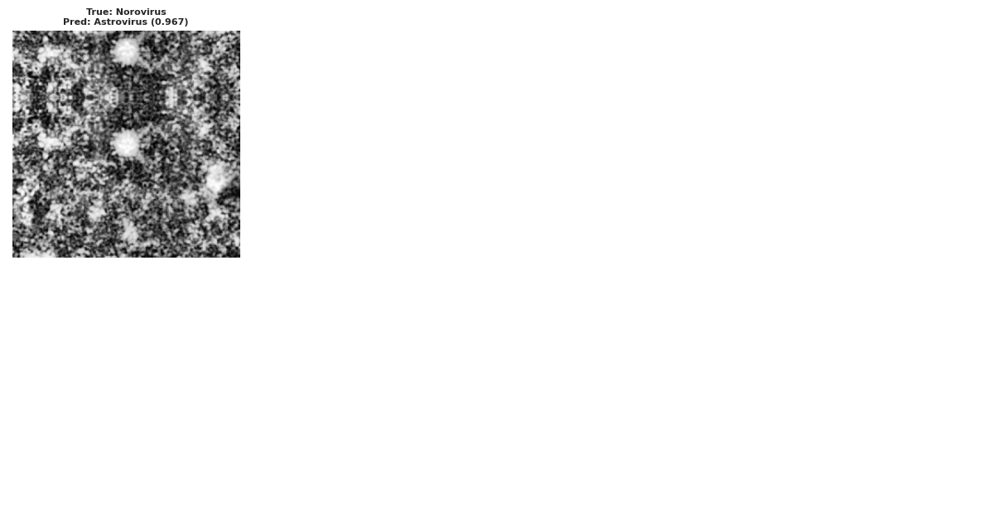

In [ ]:
if error_df.empty:
    print("Error montage not generated because no classification errors occurred.")
else:
    qualitative_by_file = {q["file_name"]: q for q in qualitative}
    montage_errors = error_df.head(8)
    fig, axes = plt.subplots(2, 4, figsize=(12.2, 6.2))
    for ax, (_, row) in zip(axes.flat, montage_errors.iterrows()):
        q = qualitative_by_file[row["File"]]
        ax.imshow(denormalize(q["image"]))
        ax.set_title(
            f"True: {row['True class']}\nPred: {row['Predicted class']} ({row['Predicted confidence']:.3f})",
            fontsize=8
        )
        ax.axis("off")
    for ax in list(axes.flat)[len(montage_errors):]:
        ax.axis("off")
    fig.tight_layout()
    save_figure(fig, "fig16a_confident_classification_errors")
    plt.show()


## 21. Embedding-space visualization

Principal component analysis is fitted to frozen test embeddings and reported with explained variance. It is descriptive and is not used to select the model or infer statistical separation.


Embeddings:   0%|          | 0/19 [00:00<?, ?it/s]

Saved: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs/figures/fig17_test_embedding_pca.png


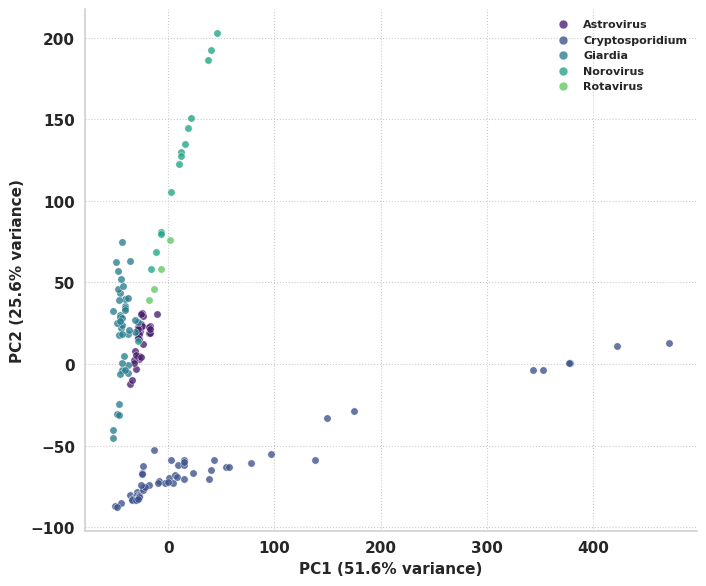

In [ ]:
from sklearn.decomposition import PCA

@torch.no_grad()
def collect_embeddings(loader):
    model.eval()
    embeddings, labels = [], []
    for batch in tqdm(loader, desc="Embeddings"):
        x = batch["image"].to(device)
        valid = batch["class_valid"].numpy().astype(bool)
        feat = model.encoder(x)[-1]
        feat = F.adaptive_avg_pool2d(feat, 1).flatten(1).cpu().numpy()
        embeddings.append(feat[valid])
        labels.extend(batch["label"].numpy()[valid].tolist())
    return np.concatenate(embeddings), np.asarray(labels)

embeddings, embedding_labels = collect_embeddings(test_loader)
pca = PCA(n_components=2, random_state=cfg.seed)
xy = pca.fit_transform(embeddings)
fig, ax = plt.subplots(figsize=(7.2, 6.0))
for c, name in enumerate(class_names):
    use = embedding_labels == c
    ax.scatter(xy[use, 0], xy[use, 1], s=28, alpha=0.78, color=PALETTE[c % len(PALETTE)], label=name, edgecolors="white", linewidths=0.35)
ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)")
ax.legend(fontsize=8, markerscale=1.2)
sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "fig17_test_embedding_pca")
plt.show()


## 22. Model complexity and inference speed

Latency is measured after warm-up on the current device at batch size 1. Report the device name and software environment together with these values because timing is hardware dependent.


In [ ]:
import time

@torch.no_grad()
def measure_latency(model, image_size, warmup=30, repetitions=100):
    model.eval()
    x = torch.randn(1, 3, image_size, image_size, device=device)
    for _ in range(warmup): model(x)
    if device.type == "cuda": torch.cuda.synchronize()
    times = []
    for _ in range(repetitions):
        start = time.perf_counter()
        model(x)
        if device.type == "cuda": torch.cuda.synchronize()
        times.append((time.perf_counter() - start) * 1000)
    return np.asarray(times)

latency = measure_latency(model, cfg.image_size)
complexity = pd.DataFrame([{
    "Encoder": cfg.encoder,
    "Parameters (M)": sum(p.numel() for p in model.parameters()) / 1e6,
    "Input size": f"{cfg.image_size}x{cfg.image_size}",
    "Device": torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU",
    "Median latency (ms/image)": np.median(latency),
    "Latency IQR (ms/image)": np.quantile(latency, 0.75) - np.quantile(latency, 0.25),
    "Throughput (images/s)": 1000 / np.median(latency),
}])
display(complexity.style.format({
    "Parameters (M)": "{:.2f}", "Median latency (ms/image)": "{:.2f}",
    "Latency IQR (ms/image)": "{:.2f}", "Throughput (images/s)": "{:.2f}"
}))
complexity.to_csv(TABLE_DIR / "model_complexity_latency.csv", index=False)


,Encoder,Parameters (M),Input size,Device,Median latency (ms/image),Latency IQR (ms/image),Throughput (images/s)
0,convnextv2_tiny.fcmae_ft_in22k_in1k,32.45,384x384,Tesla T4,24.33,0.32,41.09


## 23. Optional ablation protocol

For a defensible ablation, train each configuration from the same official training split and select its checkpoint on the same validation criterion. Run each configuration under several fixed seeds, then report the mean and standard deviation on the frozen test set. The cells below define the comparison table without inserting unobserved values.


In [ ]:
# Populate only after executing the corresponding controlled runs.
ablation_columns = [
    "Configuration", "Seed", "Accuracy", "Macro-F1", "Macro ROC-AUC",
    "Foreground macro-Dice", "Foreground macro-IoU", "Parameters (M)"
]
ablation_results = pd.DataFrame(columns=ablation_columns)

required_configs = pd.DataFrame({
    "Configuration": [
        "Classification-only ConvNeXt V2",
        "Localization-only ConvNeXt V2-FPN",
        "Shared encoder without ROI-guided pooling",
        "Full multi-task model without boundary term",
        "Full WaterPath-MTLNet",
    ],
    "Purpose": [
        "Image-classification baseline",
        "Localization baseline",
        "Effect of regional guidance",
        "Effect of boundary consistency",
        "Complete configuration",
    ]
})
display(required_configs)
required_configs.to_csv(TABLE_DIR / "ablation_protocol.csv", index=False)


,Configuration,Purpose
0,Classification-only ConvNeXt V2,Image-classification baseline
1,Localization-only ConvNeXt V2-FPN,Localization baseline
2,Shared encoder without ROI-guided pooling,Effect of regional guidance
3,Full multi-task model without boundary term,Effect of boundary consistency
4,Full WaterPath-MTLNet,Complete configuration


## 24. Repeated-run summary plot

After adding genuine repeated-run results to `ablation_results`, the following cell generates a mean ± standard deviation comparison. It intentionally raises an error when the table is empty so placeholder values cannot enter a manuscript figure.


In [ ]:
if ablation_results.empty:
    print("No ablation values plotted. Add results from executed controlled runs first.")
else:
    required = {"Configuration", "Seed", "Macro-F1", "Foreground macro-Dice"}
    if not required.issubset(ablation_results.columns):
        raise ValueError(f"Missing columns: {required - set(ablation_results.columns)}")
    summary = ablation_results.groupby("Configuration", as_index=False).agg(
        macro_f1_mean=("Macro-F1", "mean"), macro_f1_sd=("Macro-F1", "std"),
        dice_mean=("Foreground macro-Dice", "mean"), dice_sd=("Foreground macro-Dice", "std")
    )
    x = np.arange(len(summary))
    width = 0.36
    fig, ax = plt.subplots(figsize=(10.8, 5.4))
    ax.bar(x - width/2, summary["macro_f1_mean"], width, yerr=summary["macro_f1_sd"], capsize=4,
           label="Macro-F1", color=PALETTE[0])
    ax.bar(x + width/2, summary["dice_mean"], width, yerr=summary["dice_sd"], capsize=4,
           label="Foreground macro-Dice", color=PALETTE[2])
    ax.set_xticks(x, summary["Configuration"], rotation=18, ha="right")
    ax.set_ylabel("Mean score across seeds")
    ax.set_ylim(0, 1.04)
    ax.legend()
    sns.despine(ax=ax)
    fig.tight_layout()
    save_figure(fig, "fig18_ablation_repeated_runs")
    plt.show()


No ablation values plotted. Add results from executed controlled runs first.


## 25. Final export manifest

This cell lists the generated manuscript figures and tables. All numerical claims should be copied from these exported files rather than read manually from plots.


In [ ]:
artifact_rows = []
for kind, folder in (("Figure", FIG_DIR), ("Table", TABLE_DIR), ("Checkpoint", CKPT_DIR)):
    for path in sorted(folder.glob("*")):
        artifact_rows.append({"Type": kind, "File": path.name, "Path": str(path), "Size (KB)": path.stat().st_size / 1024})
artifact_manifest = pd.DataFrame(artifact_rows)
display(artifact_manifest)
artifact_manifest.to_csv(OUT / "artifact_manifest.csv", index=False)
print("All outputs:", OUT)


,Type,File,Path,Size (KB)
0,Figure,fig01_class_distribution.pdf,/content/gdrive/MyDrive/dataset/waterborne/q1_...,15.191406
1,Figure,fig01_class_distribution.png,/content/gdrive/MyDrive/dataset/waterborne/q1_...,162.449219
2,Figure,fig02_representative_samples.pdf,/content/gdrive/MyDrive/dataset/waterborne/q1_...,486.848633
3,Figure,fig02_representative_samples.png,/content/gdrive/MyDrive/dataset/waterborne/q1_...,2788.591797
4,Figure,fig02a_input_geometry_and_annotation_scale.pdf,/content/gdrive/MyDrive/dataset/waterborne/q1_...,149.700195
...,...,...,...,...
83,Checkpoint,epoch_034_waterpath_mtlnet.pt,/content/gdrive/MyDrive/dataset/waterborne/q1_...,380587.799805
84,Checkpoint,epoch_035_waterpath_mtlnet.pt,/content/gdrive/MyDrive/dataset/waterborne/q1_...,380588.299805
85,Checkpoint,epoch_036_waterpath_mtlnet.pt,/content/gdrive/MyDrive/dataset/waterborne/q1_...,380588.799805
86,Checkpoint,epoch_037_waterpath_mtlnet.pt,/content/gdrive/MyDrive/dataset/waterborne/q1_...,380589.299805


All outputs: /content/gdrive/MyDrive/dataset/waterborne/q1_outputs
